# From Peroxides to Qubits: Using Glow-Stick Chemistry to Introduce Excited States, Conical Intersections, and Quantum Computing to Undergraduates

**Journal of Chemical Education — Student Notebook (Supporting Information)**

What happens inside a glow stick when you snap it?

At first glance, it seems simple: a chemical reaction produces energy, and a dye molecule turns that energy into light. But if we zoom in on the electrons, the story becomes much more interesting. The chemistry begins with a **peroxide bond**. When that O–O bond breaks, the electronic structure of the molecule changes dramatically. As the reaction proceeds, different electronic states can approach the same energy and interact strongly. Eventually, the energy released by the chemical reaction is transferred to a dye molecule, which can then emit light. This notebook lets you follow that story computationally — starting with a simple peroxide molecule and ending with a quantum-computing description of the electronic states involved.

### What you will learn

We will build the story step by step:
1. **Warm-up: breaking H₂O₂.**
   Start with the simplest peroxide and stretch its O–O bond. You will see where the usual single-determinant description begins to break down, and how **unrestricted Hartree–Fock (UHF)** can partially describe the dissociation — but with an important price.
2. **Following the complete reaction: 1,2-dioxetane → 2 H₂CO.**
   Move from the simple warm-up to the actual chemical decomposition. Using a **state-averaged multireference method**, you will follow the reaction as first the O–O bond and then the C–C bond break. Along the way, you will track three electronic states simultaneously: the ground singlet **S₀**, the excited singlet **S₁**, and the lowest triplet **T₁**.
3. **Finding a conical intersection.**
   The S₀ and S₁ states can become degenerate during the reaction. But how do we know that a crossing is really a **conical intersection** rather than an accidental encounter? You will examine the energy landscape in the two special directions that form the **branching plane** and see the characteristic cone-shaped intersection.
4. **From orbitals to qubits.**
   Once the molecular orbitals are fixed, the active-space problem is a **CASCI** problem. You will map it onto a system of **12 qubits** and see how the electronic configurations become quantum states.
5. **VQE and SSVQE: solving the fixed-orbital problem on qubits.**
   You will use two quantum algorithms. **VQE** will find the ground state, while **SSVQE** will target S₀ and S₁ at once. Because the orbitals are kept fixed, the right classical reference for SSVQE is **CASCI in the same orbitals**.
6. **SA-OO-VQE: adding orbital optimization.**
   Finally, you will add the one ingredient that SSVQE is missing — orbital optimization — and compare the resulting **SA-OO-VQE** energies with **SA-CASSCF**, including what to do when the circuit optimization gets stuck.

A final cell collects the key results in a single **summary figure**.

### How to use this notebook
You do **not** need previous knowledge of quantum computing, and you do not need to write any code. Run the cells in order using **Shift + Enter**. Each section introduces the chemical idea first, performs the calculation, and then helps you interpret what you see. The goal is not simply to obtain numbers. Pay attention to **why the numbers change**, **when a particular electronic-structure method starts to struggle**, and **what information is preserved when we move from orbitals to qubits**.

> **A note on honesty.**
> This notebook is **not** a demonstration that quantum computers are faster than classical computers. For systems this small, classical multireference calculations are overwhelmingly more practical.
>
> Instead, this notebook asks a different question:
>
> **What happens when the chemistry itself requires several electronic configurations and several electronic states to be described at the same time?**
> That is precisely the structure of the problem that motivates many quantum-computing approaches to electronic structure.
> So the journey from **peroxide → electronic states → conical intersection → qubits** is not about claiming a quantum advantage. It is about understanding the connection between a real chemical problem and the computational language of quantum computing.

## 0. Setup

This notebook uses two open-source packages, each with a different job:
* **PySCF** performs the classical electronic-structure calculations — solving for molecular orbitals, energies, and electronic states.
* **PennyLane** is used later to build and run the quantum circuits that represent the same electronic-structure problem.

In the last section the two packages work together: PennyLane prepares the electronic states and PySCF optimizes the molecular orbitals.

All figures share one plotting style and one set of unit conversions, defined once in the setup cell below; every figure is also saved (PDF and PNG) in a folder called `figures/`.

The package versions are **pinned** so that the notebook produces consistent results and remains reproducible.

### What has been prepared for you?

Some of the calculations in this notebook would normally take considerably longer than the calculations you will run interactively. In particular, finding the geometries along the reaction pathway and locating the conical intersection requires repeated geometry optimizations.

To keep the notebook focused on the **chemistry and the ideas**, rather than waiting for optimizations to finish, these calculations have already been performed.

The file `glowstick_data.zip` contains:

* the molecular geometries along the reaction pathway,
* converged molecular orbitals that can be used to restart the electronic-structure calculations,
* data describing the conical intersection, and
* reference results for comparison.

This means that when you run a calculation in the notebook, you are generally **starting from a good initial guess rather than solving the entire problem from scratch**. Most calculations should therefore take only a few seconds.

> **Why provide the data?**
> The goal of this notebook is to let you explore *what the calculations mean*. You will still run the electronic-structure and quantum-circuit calculations yourself, but you will not have to spend several minutes repeating the computationally expensive geometry optimizations that were needed to prepare the reaction pathway.

In [1]:
%pip install -q "pyscf==2.14.*" "pennylane==0.45.*" matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt

DATA = "glowstick_data"
# The zip file is part of the Supporting Information. On Colab, upload it with the file
# browser on the left, or set URL to wherever your instructor has put it.
URL = ""            # e.g. "https://.../glowstick_data.zip"
if not os.path.isdir(DATA):
    if not os.path.exists("glowstick_data.zip") and URL:
        urllib.request.urlretrieve(URL, "glowstick_data.zip")
    with zipfile.ZipFile("glowstick_data.zip") as z:
        z.extractall(".")

geom = json.load(open(f"{DATA}/path_geometries.json"))
ref  = json.load(open(f"{DATA}/reference_results.json"))
orbs = np.load(f"{DATA}/orbitals.npz")
ints = np.load(f"{DATA}/cas_integrals.npz")
meci = np.load(f"{DATA}/meci.npz")
theta_store = np.load(f"{DATA}/ssvqe_theta.npz")
refs_store  = json.load(open(f"{DATA}/ssvqe_references.json"))
print(f"{len(geom)} geometries along the reaction path:")
print(", ".join(g["tag"] for g in geom))

16 geometries along the reaction path:
OO1.50, OO1.60, OO1.70, OO1.80, OO1.90, OO2.00, OO2.15, OO2.30, OO2.50, CC1.60, CC1.75, CC1.90, CC2.10, CC2.40, CC3.00, CC4.00


In [3]:
# ==============================================================================
# ONE PLOTTING STYLE AND ONE SET OF CONSTANTS FOR THE WHOLE NOTEBOOK
# ==============================================================================
# Every figure uses the same fonts, inward ticks and colour-blind-safe Okabe-Ito
# colours. For the electronic states, a colour always means the same thing:
#     green = S0      blue = S1      vermillion = T1
# Figures that compare *methods* (Section 1) or *directions* (Section 3) reuse the
# same palette; their legends say what each colour stands for.
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",      # Computer Modern (LaTeX-like) mathematics
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "xtick.direction": "in",       # inward-facing tick marks
        "ytick.direction": "in",
        "xtick.top": True,             # ticks on all four sides
        "ytick.right": True,
        "lines.linewidth": 1.5,
        "lines.markersize": 6.0,
        "savefig.bbox": "tight",
    }
)

OKABE_ITO = dict(green="#009E73", blue="#0072B2", vermillion="#D55E00",
                 orange="#E69F00", purple="#CC79A7", skyblue="#56B4E9", grey="#555555")
COLOR_S0, COLOR_S1, COLOR_T1 = OKABE_ITO["green"], OKABE_ITO["blue"], OKABE_ITO["vermillion"]

# Unit conversions (CODATA 2018)
HARTREE_TO_KCAL = 627.5094740631     # kcal/mol per hartree
HARTREE_TO_EV = 27.211386245988      # eV per hartree
BOHR = 0.529177210903                # angstrom per bohr

# All figures are also written to the folder "figures/" as vector PDF and 600-dpi PNG.
os.makedirs("figures", exist_ok=True)

def save_figure(fig, name):
    fig.savefig(f"figures/{name}.pdf")
    fig.savefig(f"figures/{name}.png", dpi=600)


---
## 1. Warm-up: breaking the O–O bond of hydrogen peroxide

Peroxide chemistry is at the heart of many chemiluminescent reactions — from **glow sticks** and fireflies to forensic luminol. The common feature is a peroxide **O–O single bond**. The simplest peroxide is hydrogen peroxide, H–O–O–H. We will use it as a warm-up because it lets us see, in a very simple molecule, an important idea that will become central later:
> **A chemical bond can be easy to describe near equilibrium but require several electronic configurations as it breaks.**

### Three ways to describe the same bond
We will stretch the O–O bond and describe it using three electronic-structure methods:

| Method          | Wavefunction                                                             | What happens as the O–O bond breaks?                                             |
| --------------- | ------------------------------------------------------------------------ | -------------------------------------------------------------------------------- |
| **RHF**         | One closed-shell determinant with paired electrons in σ(O–O)             | Works well near equilibrium, but struggles as the bond dissociates               |
| **UHF**         | One determinant in which the α and β orbitals can become different       | Can lower the dissociation energy, but does so by introducing spin contamination |
| **CASSCF(2,2)** | A multiconfigurational wavefunction containing σ² and σ*² configurations | Describes the changing electronic character of the bond throughout dissociation  |

The important difference is **not simply that one method is more accurate than another**. As the O–O bond stretches, the two electrons that form the bond no longer have a clear reason to remain paired in the bonding orbital. A good description therefore needs to allow both $\sigma^2$ and $\sigma^{*2}$ to contribute to the wavefunction.

This is the first place where we will encounter **multireference character**: more than one electronic configuration becomes important for describing the same chemical state.

### Which two orbitals go into the active space?
CASSCF(2,2) is only meaningful if the two active orbitals really are σ(O–O) and σ*(O–O). It is tempting to take the highest occupied and lowest unoccupied RHF orbitals (HOMO and LUMO), but near equilibrium the HOMO of H₂O₂ is an oxygen **lone-pair** combination, not the O–O σ bond. With HOMO/LUMO as the active space, the calculation would correlate the wrong pair of electrons (Question 1.3 lets you try this).

So we let the molecule tell us which orbitals matter:
1. At the **longest** O–O distance, the broken-symmetry UHF solution has two natural orbitals with occupations close to 1. Those are σ and σ*: they are exactly the orbitals in which the two bonding electrons are separating.
2. We start the scan there and **follow these orbitals inward**: the converged CASSCF orbitals at each distance are the starting guess for the next, shorter distance.

Following orbitals along a scan like this is standard practice in multireference calculations.

### What should you watch?
As you stretch the O–O bond, keep an eye on three quantities:
1. **The energy.**
   How does each method describe the energetic cost of breaking the bond?
2. **The natural-orbital occupations.**
   These tell us how the electrons are distributed between the bonding orbital σ and antibonding orbital σ*. Near equilibrium, we expect approximately two electrons in σ and almost none in σ*. As the bond breaks, the occupations move toward a more balanced distribution.
3. **UHF's $\langle \hat{S}^2\rangle$.**
   Hydrogen peroxide is a singlet, so a pure singlet wavefunction has $\langle \hat{S}^2\rangle = 0$.
   If the UHF value starts to increase, the UHF wavefunction is no longer a pure spin eigenstate. This is called **spin contamination**.
Together, these three quantities tell a much more complete story than the energy alone.

> **The key lesson:**
> When a bond is close to equilibrium, one electronic configuration can often provide an excellent description. As the bond breaks, that simple picture can stop being adequate. The wavefunction itself has to change.

In [4]:
from pyscf import gto, scf, mcscf

def h2o2(rOO, basis="6-31g*"):
    """H2O2 with the O-O distance we choose; the O-H bonds and the H-O-O-H twist
    are kept fixed at their equilibrium values."""
    return gto.M(atom=f"""
    O
    O 1 {rOO}
    H 1 0.966 2 100.0
    H 2 0.966 1 100.0 3 112.0""", basis=basis, verbose=0)

def broken_symmetry_uhf(mf, dm0=None):
    """Generate a broken-symmetry UHF solution from an RHF reference.

    The RHF HOMO and LUMO are mixed with opposite signs for alpha
    and beta spins, allowing the two unpaired electrons to localize
    on different oxygens as the O-O bond is stretched. If dm0 (the UHF
    density of a neighbouring geometry) is given, it is used as the guess instead."""
    mol = mf.mol; nocc = mol.nelectron // 2
    C = mf.mo_coeff
    homo = C[:, nocc - 1]; lumo = C[:, nocc]                 # RHF HOMO and LUMO
    Ca = C.copy(); Cb = C.copy()                             # alpha / beta orbitals
    Ca[:, nocc - 1] = (homo + lumo) / np.sqrt(2.0)
    Cb[:, nocc - 1] = (homo - lumo) / np.sqrt(2.0)
    Da = Ca[:, :nocc] @ Ca[:, :nocc].T                       # alpha density matrix
    Db = Cb[:, :nocc] @ Cb[:, :nocc].T                       # beta density matrix

    umf = scf.UHF(mol); umf.verbose = 0
    umf.kernel((Da, Db) if dm0 is None else dm0)
    s2 = umf.spin_square()[0]                                # <S^2> of the UHF determinant
    return umf, s2

def uhf_natural_orbitals(umf):
    """Natural orbitals of the total (alpha + beta) UHF density, sorted from
    occupation 2 down to 0. For a breaking bond, the sigma / sigma* pair shows up
    as the two natural orbitals with occupations closest to 1."""
    S = umf.get_ovlp()
    dm = umf.make_rdm1()[0] + umf.make_rdm1()[1]
    w, v = np.linalg.eigh(S)                                 # orthogonalize the AO basis
    S_half, S_inv_half = v @ np.diag(w ** 0.5) @ v.T, v @ np.diag(w ** -0.5) @ v.T
    occ, u = np.linalg.eigh(S_half @ dm @ S_half)
    order = np.argsort(-occ)
    return occ[order], (S_inv_half @ u)[:, order]


In [5]:
distances = np.round(np.arange(1.2, 3.61, 0.2), 2)     # O-O distances in angstrom

rows = []
C_prev, dm_prev = None, None
for r in sorted(distances, reverse=True):               # from the stretched bond inward
    mol = h2o2(r)
    mf = scf.RHF(mol); mf.verbose = 0; mf.kernel()       # RHF
    umf, s2 = broken_symmetry_uhf(mf)                    # broken-symmetry UHF
    if s2 < 0.1 and dm_prev is not None:                 # collapsed back to RHF? Also try the
        umf_2, s2_2 = broken_symmetry_uhf(mf, dm0=dm_prev)   # UHF density of the previous point
        if umf_2.e_tot < umf.e_tot - 1e-6:
            umf, s2 = umf_2, s2_2
    if s2 > 0.1:
        dm_prev = umf.make_rdm1()

    # CASSCF(2,2): two electrons in sigma(O-O) / sigma*(O-O)
    mc = mcscf.CASSCF(mf, 2, 2); mc.verbose = 0
    mc.natorb = True; mc.fix_spin_(ss=0)
    if C_prev is None:
        # first (longest) distance: the UHF natural orbitals with occupations closest to 1
        occ_uhf, no = uhf_natural_orbitals(umf)
        nocc = mol.nelectron // 2
        k = int(np.argmin(np.abs(occ_uhf[:nocc] - 1.0)))
        guess = mcscf.sort_mo(mc, no, [k + 1, nocc + 1], base=1)
    else:
        # every other distance: follow the CASSCF orbitals of the previous (longer) distance
        guess = mcscf.project_init_guess(mc, C_prev)
    mc.kernel(guess)
    C_prev = mc.mo_coeff

    # natural-orbital occupations of the two active orbitals
    n_sigma, n_sigma_star = mc.mo_occ[mc.ncore:mc.ncore + 2]
    rows.append((r, mf.e_tot, umf.e_tot, mc.e_tot, n_sigma, n_sigma_star, s2))

rows.sort()                                              # back to increasing r(O-O)
print(f"{'r(O-O)/A':>9} {'RHF':>12} {'UHF':>12} {'CASSCF(2,2)':>14} "
      f"{'n(sigma)':>10} {'n(sigma*)':>11} {'<S^2>_UHF':>11}")
for r, e_rhf, e_uhf, e_cas, n1, n2, s2 in rows:
    print(f"{r:9.2f} {e_rhf:12.6f} {e_uhf:12.6f} {e_cas:14.6f} {n1:10.3f} {n2:11.3f} {s2:11.3f}")


 r(O-O)/A          RHF          UHF    CASSCF(2,2)   n(sigma)   n(sigma*)   <S^2>_UHF
     1.20  -150.712836  -150.712836    -150.736797      1.979       0.021       0.000
     1.40  -150.761357  -150.761357    -150.800405      1.943       0.057       0.000
     1.60  -150.740455  -150.748444    -150.801196      1.868       0.132       0.371
     1.80  -150.698821  -150.752632    -150.787435      1.744       0.256       0.762
     2.00  -150.654491  -150.758976    -150.774891      1.589       0.411       0.905
     2.20  -150.613892  -150.762421    -150.766577      1.438       0.562       0.963
     2.40  -150.578751  -150.763702    -150.761592      1.313       0.687       0.989
     2.60  -150.549051  -150.764008    -150.758785      1.218       0.782       1.001
     2.80  -150.524150  -150.763954    -150.757264      1.147       0.853       1.006
     3.00  -150.503359  -150.763748    -150.756405      1.097       0.903       1.009
     3.20  -150.486157  -150.763471    -150.755853    

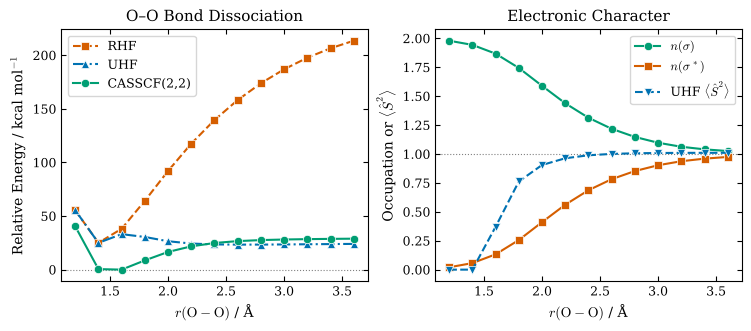

In [6]:
# ==============================================================================
# 1. COLOURS (style and constants come from the setup cell)
# ==============================================================================

# Colours here label METHODS (Okabe-Ito palette from the setup cell)
COLOR_RHF = OKABE_ITO["vermillion"]
COLOR_UHF = OKABE_ITO["blue"]
COLOR_CAS = OKABE_ITO["green"]

# ==============================================================================
# 2. DATA PREPARATION & CONVERSIONS
# ==============================================================================
# Unpack results array
r, e_rhf, e_uhf, e_cas, n_sigma, n_sigmastar, s2 = map(
    np.array, zip(*rows)
)

# Reference energy
e_reference = e_cas.min()  # Minimum CASSCF energy as zero point

# Relative energies in kcal/mol
relative_e_rhf = (e_rhf - e_reference) * HARTREE_TO_KCAL
relative_e_uhf = (e_uhf - e_reference) * HARTREE_TO_KCAL
relative_e_cas = (e_cas - e_reference) * HARTREE_TO_KCAL

# ==============================================================================
# 3. FIGURE INITIALIZATION
# ==============================================================================
# Create a 1-row, 2-column figure (7.4 in wide x 3.2 in tall)
fig, (ax_energy, ax_wavefunction) = plt.subplots(
    1, 2, figsize=(7.4, 3.2), layout="constrained"
)

# ==============================================================================
# 4. LEFT PANEL: RELATIVE ENERGIES
# ==============================================================================
# Baseline zero reference line
ax_energy.axhline(0.0, color="gray", linestyle=":", linewidth=0.8, zorder=1)

# Plot each electronic structure method individually
ax_energy.plot(
    r,
    relative_e_rhf,
    label="RHF",
    color=COLOR_RHF,
    linestyle="--",
    marker="s",
    markeredgecolor="white",
    markeredgewidth=0.5,
)

ax_energy.plot(
    r,
    relative_e_uhf,
    label="UHF",
    color=COLOR_UHF,
    linestyle="-.",
    marker="^",
    markeredgecolor="white",
    markeredgewidth=0.5,
)

ax_energy.plot(
    r,
    relative_e_cas,
    label="CASSCF(2,2)",
    color=COLOR_CAS,
    linestyle="-",
    marker="o",
    markeredgecolor="white",
    markeredgewidth=0.5,
)

# Labels, title, and legend for left panel
ax_energy.set_xlabel(r"$r(\mathrm{O-O})$ / Å")
ax_energy.set_ylabel(r"Relative Energy / kcal mol$^{-1}$")
ax_energy.set_title("O–O Bond Dissociation")
ax_energy.legend(loc="upper left")

# ==============================================================================
# 5. RIGHT PANEL: WAVEFUNCTION CHARACTER
# ==============================================================================
# Reference line at occupation/spin = 1.0
ax_wavefunction.axhline(
    1.0, color="gray", linestyle=":", linewidth=0.8, zorder=1
)

# Plot occupations and spin expectation value
ax_wavefunction.plot(
    r,
    n_sigma,
    label=r"$n(\sigma)$",
    color=COLOR_CAS,
    linestyle="-",
    marker="o",
    markeredgecolor="white",
    markeredgewidth=0.5,
)

ax_wavefunction.plot(
    r,
    n_sigmastar,
    label=r"$n(\sigma^*)$",
    color=COLOR_RHF,
    linestyle="-",
    marker="s",
    markeredgecolor="white",
    markeredgewidth=0.5,
)

ax_wavefunction.plot(
    r,
    s2,
    label=r"UHF $\langle \hat{S}^2 \rangle$",
    color=COLOR_UHF,
    linestyle="--",
    marker="v",
    markeredgecolor="white",
    markeredgewidth=0.5,
)

# Labels, title, and legend for right panel
ax_wavefunction.set_xlabel(r"$r(\mathrm{O-O})$ / Å")
ax_wavefunction.set_ylabel(r"Occupation or $\langle \hat{S}^2 \rangle$")
ax_wavefunction.set_title("Electronic Character")
ax_wavefunction.legend(loc="upper right")

# ==============================================================================
# 6. OPTIONAL: ADD MOLECULAR STRUCTURE INSET (H2O2)
# ==============================================================================
# To add a molecule image, uncomment the lines below and provide an image path:
#
# img = plt.imread("h2o2_structure.png")
# ax_inset = ax_energy.inset_axes([0.55, 0.55, 0.38, 0.38])  # [x, y, width, height]
# ax_inset.imshow(img)
# ax_inset.axis("off")  # Turn off axes for the image

# ==============================================================================
# 7. EXPORT FIGURES
# ==============================================================================
# Save as publication-quality PDF (vector) and PNG (raster)
save_figure(fig, "OO_dissociation")

plt.show()

### What should you see?
Near the equilibrium O–O bond length (about 1.4–1.5 Å), all three methods give a similar description. At 1.4 Å the natural-orbital occupations are approximately $(1.94,\;0.06)$: almost all of the two electrons occupy the bonding orbital σ, with very little occupation of the antibonding orbital σ*. In this region, **one electronic configuration is a very good approximation**.

As the O–O bond stretches, however, the picture changes. The RHF energy rises steeply — at 3.6 Å it lies about 185 kcal mol⁻¹ above CASSCF(2,2) — while the natural-orbital occupations move toward $(1.03,\;0.97)$.

What does this mean?
At large separation, the two electrons no longer behave like a conventional two-electron bond. Each electron becomes associated with a different oxygen atom. To describe this correctly, the wavefunction needs contributions from two configurations:
$\sigma^2$ and $\sigma^{*2}$. At dissociation, these configurations become comparable in importance. In other words, **there is no longer one dominant configuration**.

This is the numerical signature of **multireference character**.
> **Multireference does not simply mean “the method is complicated.”**
> It means that several electronic configurations are genuinely needed to describe the same physical state.

### What about UHF?
UHF takes a different route. Instead of explicitly combining multiple configurations, it allows the α and β electrons to occupy different spatial orbitals. Up to about 1.5 Å the best UHF solution *is* the RHF solution ($\langle \hat S^2\rangle = 0$); beyond that point (the **Coulson–Fischer point**) a lower-energy, spin-broken solution appears. Its energy therefore behaves much better than RHF. But there is a trade-off. For a pure singlet, $\langle \hat S^2\rangle = 0$. As the O–O bond is stretched, the UHF value increases toward approximately $\langle \hat S^2\rangle \approx 1$. The UHF determinant is therefore no longer a pure singlet. At dissociation, it can be understood as containing equal contributions from singlet and triplet spin character.

So UHF has exchanged one problem for another:
> **It can describe the bond dissociation energetically, but the resulting wavefunction no longer has a well-defined total spin.**

This distinction will become important in the next section, where we need to describe **singlet and triplet states separately**.

### A note on the bond energy
None of these three methods gives an accurate O–O bond energy. CASSCF(2,2) binds H₂O₂ by only about 29 kcal mol⁻¹ (the energy difference between its minimum and 3.6 Å), roughly half of the experimental value of about 50 kcal mol⁻¹. UHF even places the separated fragments slightly *below* the RHF minimum. CASSCF(2,2) gets the **character** of the wavefunction right, but it leaves out the **dynamic correlation** of all the other electrons. We will add dynamic correlation explicitly (with NEVPT2) in Part 2.

---

### Questions

> **Question 1.1.**
> At an O–O distance of 3.6 Å, the natural-orbital occupations are approximately $(1.0,\,1.0)$.
>
> 1. Write down the two electronic configurations that become important.
> 2. Explain why neither configuration by itself gives the correct dissociation picture.
> 3. Why does a single determinant fail to represent the required combination of configurations?

> **Question 1.2.**
> Why is spin contamination, indicated by $\langle \hat S^2\rangle \neq 0$, a problem if we want to distinguish **singlet** and **triplet** states?
>
> Think ahead to the next section: if a calculation gives a mixture of singlet and triplet character, how would you know which energy belongs to the singlet state and which belongs to the triplet?

> **Question 1.3.**
> Repeat the CASSCF(2,2) calculation at 1.4 Å, but use the RHF HOMO and LUMO as the active orbitals:
> ```python
> mf = scf.RHF(h2o2(1.4)); mf.verbose = 0; mf.kernel()
> mc = mcscf.CASSCF(mf, 2, 2); mc.verbose = 0; mc.natorb = True; mc.kernel(mf.mo_coeff)
> print(mc.e_tot, mc.mo_occ[mc.ncore:mc.ncore + 2])
> ```
> Compare the energy and the occupations with the table above. Which electrons does this calculation correlate? Why is a *higher* CASSCF energy a sign that the wrong active space was chosen?


## 2. The whole reaction: 1,2-dioxetane → 2 formaldehyde

The simple H₂O₂ calculation showed us what happens when a single peroxide bond breaks. Now we move to a molecule that captures much more of the chemistry behind chemiluminescence: **1,2-dioxetane**.  The actual peroxide chemistry in a glow stick involves a strained peroxide intermediate, **1,2-dioxetanedione**, formed in the reaction of hydrogen peroxide with an oxalate ester. For understanding the electronic structure, however, we will use **1,2-dioxetane** as a simpler model system.

Why is this molecule interesting?
It contains **two bonds that eventually break**, and the order in which they break changes the electronic structure of the molecule.
The reaction can be pictured as:

$$
\text{O–O cleavage}
\;\longrightarrow\;
\text{biradical}
\;\longrightarrow\;
\text{C–C cleavage}
\;\longrightarrow\;
2\,\mathrm{H_2CO}.
$$

The first step opens the strained four-membered ring and produces a **biradical-like intermediate**. The second step separates the two carbon fragments, producing two formaldehyde molecules. **But there is an important twist.** The products do not have to be produced only in their electronic ground states. The reaction can generate **electronically excited formaldehyde**. When that excited molecule subsequently relaxes, the excess electronic energy can be released as a photon. That is the connection to **chemiluminescence**: the chemistry creates an electronically excited state, and the excited molecule can then emit light.

### Why do we need three electronic states?
Along the reaction pathway, we will follow three states simultaneously:
* **S₀** — the ground-state singlet,
* **S₁** — the lowest excited singlet,
* **T₁** — the lowest triplet.
Here, **S** denotes a singlet state and **T** a triplet state.

Following all three is important because the electronic character of the reaction changes as the bonds break. In particular, the biradical region contains several configurations and electronic states that are close in energy. This is exactly the situation where the single-configuration methods from the H₂O₂ warm-up become inadequate.

### The electronic-structure method: SA-CASSCF(8,6)
To describe this changing electronic structure, we use **state-averaged complete active space self-consistent field**, or **SA-CASSCF(8,6)**. The notation means: * **8** electrons are correlated explicitly in the active space and **6** molecular orbitals are included in that active space. 

The six orbitals are chosen to capture the chemically important electrons: * σ and σ* of the **O–O bond**, σ and σ* of the **C–C bond**,
and the two oxygen **p-type lone-pair orbitals**. The calculation is **state averaged** over S₀ and S₁. In practice, this means that the orbitals are optimized using an equal weighting of the two states rather than optimizing exclusively for the ground state.

Why do that?
Imagine S₀ and S₁ approaching one another along the reaction coordinate. If we optimized the orbitals only for S₀, the calculation could produce orbitals that are particularly good for S₀ but poorly suited to describing S₁.

State averaging instead asks for a set of orbitals that provides a balanced description of **both states**.

> **Two things are optimized in SA-CASSCF.**
> 1. the **CI coefficients** — how much each electronic configuration contributes to S₀ and S₁, and
> 2. the **molecular orbitals** themselves.
>
> If the orbitals are kept fixed and only the CI coefficients are optimized, the method is called **CASCI** (complete active space configuration interaction). Keep this distinction in mind: it is exactly the difference between the two quantum algorithms in Sections 5 and 6.

> **The key idea:**
> In the H₂O₂ example, we learned that bond breaking can make several electronic configurations important. Here, several configurations **and several electronic states** become important at the same time. **That is why a multireference, state-averaged description is useful for following the reaction.**

In [7]:
from pyscf import fci

def make_mol(X, basis="6-31g*", spin=0):
    sym = ["O", "O", "C", "C", "H", "H", "H", "H"]      # ring: O1-O2-C3-C4
    return gto.M(atom=[[s, x] for s, x in zip(sym, X)], basis=basis,
                 spin=spin, unit="A", verbose=0)

def sa_casscf(X, C, nstates=2):
    """State-averaged CASSCF(8,6), restarted from the supplied orbitals."""
    mol = make_mol(X)
    mf = scf.RHF(mol); mf.verbose = 0; mf.kernel()
    mc = mcscf.CASSCF(mf, 6, 8)
    mc.fcisolver.nroots = nstates
    mc = mc.state_average_([1 / nstates] * nstates)
    mc.fix_spin_(ss=0)          # keep the two states singlets
    mc.natorb = True            # report state-averaged natural orbitals
    mc.verbose = 0
    mc.kernel(mcscf.project_init_guess(mc, C))
    return mc

def triplet(mc):
    """Lowest triplet in the same orbitals (4 electrons up, 4-2 down)."""
    ct = mcscf.CASCI(mc._scf, 6, (5, 3)); ct.verbose = 0
    ct.kernel(mc.mo_coeff)
    return float(np.atleast_1d(ct.e_tot)[0])

def character(mc, state=0):
    """Two measures of multiconfigurational character:
    the weight of the leading determinant and the number of effectively
    unpaired electrons N_u = sum_i min(n_i, 2-n_i)."""
    ci = mc.ci[state]
    dm1 = fci.direct_spin1.make_rdm1(ci, 6, (4, 4))
    occ = np.linalg.eigvalsh(dm1)
    return float(np.max(ci ** 2)), float(np.sum(np.minimum(occ, 2 - occ)))

### Dynamic correlation, cheaply

CASSCF describes the *few* orbitals and configurations that change as the reaction proceeds — that is its job. But it does not capture all of the smaller, more diffuse **dynamic correlation** associated with the remaining electrons. This missing correlation contributes to the quantitative accuracy of the energies, including the height of the reaction barrier.

We add this contribution with **NEVPT2**, a second-order perturbation theory applied on top of the CASSCF states. For this small system, the additional calculation takes only a couple of seconds per state.

In [8]:
from pyscf import mrpt
import time

def nevpt2(mc):
    """NEVPT2 correction for S0, S1 and T1 in the state-averaged orbitals."""
    ci = mcscf.CASCI(mc._scf, 6, 8); ci.fcisolver.nroots = 2; ci.verbose = 0
    fci.addons.fix_spin_(ci.fcisolver, ss=0)
    ci.kernel(mc.mo_coeff)
    E = [float(ci.e_tot[k] + mrpt.NEVPT(ci, root=k).kernel()) for k in (0, 1)]
    ct = mcscf.CASCI(mc._scf, 6, (5, 3)); ct.verbose = 0; ct.kernel(mc.mo_coeff)
    ET = float(np.atleast_1d(ct.e_tot)[0] + mrpt.NEVPT(ct).kernel())
    return E, ET

Now we can compute the **entire reaction path in one pass**. Each geometry is restarted from the converged orbitals supplied with the notebook, so the 16 geometries together take well under a minute. The computationally expensive part — the geometry optimizations used to generate the reaction path — has already been done for you.

In [9]:
results = []
t0 = time.time()
print(f"{'point':>7} {'r(O-O)':>7} {'r(C-C)':>7} {'S0':>11} {'S1':>11} {'T1':>11} "
      f"{'gap/eV':>7} {'c0^2':>6} {'N_u':>5}")
for g in geom:
    X = np.array(g["X"])
    mc = sa_casscf(X, orbs[g["tag"]])      # state-averaged CASSCF(8,6): S0 and S1
    tT = triplet(mc)                       # lowest triplet in the same orbitals
    c0, nu = character(mc, 0)              # how multiconfigurational is S0?
    E_pt, ET_pt = nevpt2(mc)               # + dynamic correlation
    results.append(dict(tag=g["tag"], rOO=g["rOO"], rCC=g["rCC"],
                        S0=mc.e_states[0], S1=mc.e_states[1], T1=tT,
                        S0_pt=E_pt[0], S1_pt=E_pt[1], T1_pt=ET_pt, c0=c0, nu=nu))
    r = results[-1]
    print(f"{g['tag']:>7} {g['rOO']:7.2f} {g['rCC']:7.2f} {r['S0_pt']:11.5f} "
          f"{r['S1_pt']:11.5f} {r['T1_pt']:11.5f} "
          f"{HARTREE_TO_EV*(r['S1_pt']-r['S0_pt']):7.3f} {c0:6.2f} {nu:5.2f}", flush=True)
print(f"\n({time.time()-t0:.0f} s in total; energies in hartree include NEVPT2)")

# ---- Check 1: do your SA-CASSCF energies agree with the reference values supplied? ----
supplied = {x["tag"]: x["exact"] for x in ref["quantum"]}
dev = max(max(abs(r["S0"] - supplied[r["tag"]][0]), abs(r["S1"] - supplied[r["tag"]][1]))
          for r in results)
print(f"largest difference from the supplied SA-CASSCF energies: {dev*HARTREE_TO_KCAL:.1e} kcal/mol")

# ---- Check 2: how much of the barrier comes from dynamic correlation? ------------------
ring = [r for r in results if r["tag"].startswith("OO")]          # the O-O stretch
top = max(ring, key=lambda r: r["S0_pt"])                          # highest S0 point
b_cas = (max(r["S0"] for r in ring) - ring[0]["S0"]) * HARTREE_TO_KCAL
b_pt = (top["S0_pt"] - ring[0]["S0_pt"]) * HARTREE_TO_KCAL
print(f"highest S0 point on the O-O stretch: {top['tag']}")
print(f"   barrier, SA-CASSCF only : {b_cas:5.1f} kcal/mol")
print(f"   barrier, with NEVPT2    : {b_pt:5.1f} kcal/mol")


  point  r(O-O)  r(C-C)          S0          S1          T1  gap/eV   c0^2   N_u


 OO1.50    1.50    1.52  -228.23969  -228.07651  -228.11698   4.440   0.94  0.24


 OO1.60    1.60    1.52  -228.23518  -228.11186  -228.14723   3.356   0.91  0.34


 OO1.70    1.70    1.51  -228.22762  -228.13362  -228.16300   2.558   0.88  0.47


 OO1.80    1.80    1.51  -228.21860  -228.14890  -228.17224   1.896   0.84  0.63


...

 CC2.10    3.09    2.10  -228.29529  -228.16001  -228.17203   3.681   0.87  0.38


 CC2.40    3.53    2.41  -228.31742  -228.16507  -228.17978   4.146   0.89  0.35


 CC3.00    3.50    3.00  -228.32961  -228.17349  -228.18839   4.248   0.89  0.35


 CC4.00    3.48    4.00  -228.32987  -228.17354  -228.18879   4.254   0.89  0.35



(38 s in total; energies in hartree include NEVPT2)
largest difference from the supplied SA-CASSCF energies: 2.2e-03 kcal/mol
highest S0 point on the O-O stretch: OO2.30
   barrier, SA-CASSCF only :   4.3 kcal/mol
   barrier, with NEVPT2    :  27.9 kcal/mol


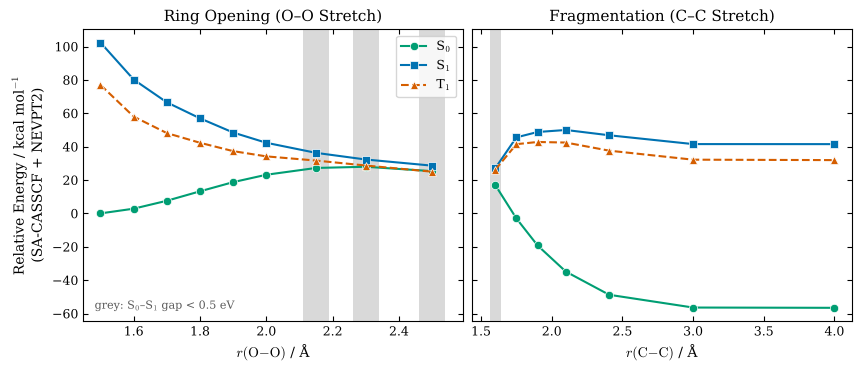

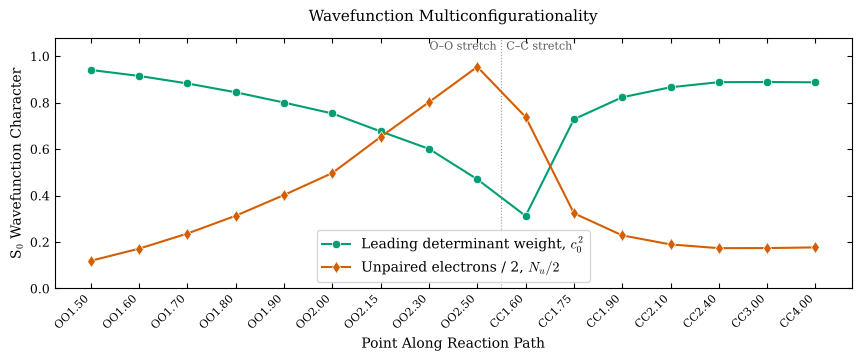

In [10]:
# Energies relative to the reactant S0 (first point), in kcal/mol, with NEVPT2
ref0 = results[0]["S0_pt"]
A = [r for r in results if r["tag"].startswith("OO")]      # ring opening
B = [r for r in results if r["tag"].startswith("CC")]      # fragmentation
GAP_WINDOW_EV = 0.5                                          # "near-degenerate": S0-S1 gap below this

# ==============================================================================
# FIGURE 1: STATE ENERGIES ALONG THE TWO STRETCHES
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.6), sharey=True, layout="constrained")

for a, P, xk, lab, ttl in [
    (ax[0], A, "rOO", r"$r(\mathrm{O{-}O})$ / Å", "Ring Opening (O–O Stretch)"),
    (ax[1], B, "rCC", r"$r(\mathrm{C{-}C})$ / Å", "Fragmentation (C–C Stretch)"),
]:
    x = np.array([p[xk] for p in P])
    e = {s: np.array([(p[s + "_pt"] - ref0) * HARTREE_TO_KCAL for p in P]) for s in ("S0", "S1", "T1")}

    # light grey band: points where the S0-S1 gap is below GAP_WINDOW_EV
    near = (e["S1"] - e["S0"]) / HARTREE_TO_KCAL * HARTREE_TO_EV < GAP_WINDOW_EV
    for xi in x[near]:
        a.axvspan(xi - 0.04, xi + 0.04, color="0.85", lw=0, zorder=0)

    a.plot(x, e["S0"], "o-", color=COLOR_S0, label=r"S$_0$", markeredgecolor="white", markeredgewidth=0.5)
    a.plot(x, e["S1"], "s-", color=COLOR_S1, label=r"S$_1$", markeredgecolor="white", markeredgewidth=0.5)
    a.plot(x, e["T1"], "^--", color=COLOR_T1, label=r"T$_1$", markeredgecolor="white", markeredgewidth=0.5)
    a.set_xlabel(lab)
    a.set_title(ttl)

ax[0].set_ylabel(r"Relative Energy / kcal mol$^{-1}$" + "\n" + r"(SA-CASSCF + NEVPT2)")
ax[0].legend(loc="upper right")
ax[0].text(0.03, 0.04, rf"grey: S$_0$–S$_1$ gap < {GAP_WINDOW_EV} eV", transform=ax[0].transAxes,
           fontsize=8, color="0.35")

save_figure(fig, "reaction_energies")
plt.show()

# ==============================================================================
# FIGURE 2: GROUND-STATE WAVEFUNCTION CHARACTER
# ==============================================================================
fig, ax = plt.subplots(figsize=(8.5, 3.5), layout="constrained")
idx = range(len(results))
ax.plot(idx, [r["c0"] for r in results], "o-", color=COLOR_S0,
        label=r"Leading determinant weight, $c_0^2$", markeredgecolor="white", markeredgewidth=0.5)
ax.plot(idx, [r["nu"] / 2 for r in results], "d-", color=COLOR_T1,
        label=r"Unpaired electrons / 2, $N_u/2$", markeredgecolor="white", markeredgewidth=0.5)
ax.axvline(len(A) - 0.5, color="0.6", ls=":", lw=0.8)                 # O-O part | C-C part
ax.text(len(A) - 0.6, 1.065, "O–O stretch", ha="right", va="top", fontsize=8, color="0.35")
ax.text(len(A) - 0.4, 1.065, "C–C stretch", ha="left", va="top", fontsize=8, color="0.35")

ax.set_ylim(0, 1.08)
ax.set_xticks(list(idx))
ax.set_xticklabels([r["tag"] for r in results], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Point Along Reaction Path")
ax.set_ylabel(r"S$_0$ Wavefunction Character")
ax.set_title("Wavefunction Multiconfigurationality", pad=12)
ax.legend(fontsize=10, loc="lower center")

save_figure(fig, "wavefunction_character")
plt.show()


### What should you see?
The reaction path tells us much more than simply which bonds break.
* **Breaking the O–O bond costs about 28 kcal mol⁻¹.**
  The highest S₀ point on the O–O stretch (OO2.30) lies about 28 kcal mol⁻¹ above the reactant. The experimental activation energy is approximately 23 kcal mol⁻¹, so the calculation gives a reasonable estimate for such a small active space and modest basis set. Notice the second check printed below the table: **without NEVPT2 the barrier is only about 4 kcal mol⁻¹**. The active space describes *which* configurations compete, but most of the barrier height comes from the dynamic correlation of the other electrons, just as the H₂O₂ bond energy did in Part 1.
* **Around $r(\mathrm{O-O}) \approx 2.2\text{–}2.5$ Å, the three electronic states come very close in energy (grey bands).**
  The S₀–S₁ gap shrinks to about 0.14 eV (3 kcal mol⁻¹) at OO2.50, and T₁ is practically degenerate with S₀. In this region, the molecule has strong **biradical character**: roughly one unpaired electron is associated with each oxygen. This creates a region where the electronic state of the molecule can change particularly easily.
* **The C–C bond then breaks, and the energy drops toward the products.**
  The two formaldehyde molecules are formed, but they do not necessarily emerge in their electronic ground states. The excited states correlate with electronically excited formaldehyde, with excitation energies of about **4.3 eV for S₁** and **3.8 eV for T₁** relative to the ground-state products. These are *vertical* values, at the ground-state product geometry; relaxing the excited formaldehyde lowers them (Extension 6).

There is also a useful way to see that the **wavefunction itself is changing** along the reaction.

For the ground state, the leading determinant accounts for about **94% of the wavefunction in the reactant**. Through the biradical region that weight falls steadily, to **0.47 at OO2.50** and **0.31 at CC1.60**, while the number of effectively unpaired electrons $N_u$ approaches **2** (1.91 at OO2.50). Of the two measures, $N_u$ is the more robust: $c_0^2$ is the weight of a single *determinant*, and an open-shell singlet is spread over two determinants by its spin coupling alone, which is why $c_0^2$ dips furthest at CC1.60.

So this is not simply a molecule changing its geometry.

> **The electronic character of the molecule is changing as the reaction proceeds.**

That is exactly why a single-reference description becomes inadequate in this part of the reaction.

### So, which excited state produces the light?
Here we need to distinguish the **model reaction** from what happens in an actual glow stick. The energy that can end up in the products is the reaction energy *plus* the barrier that has already been climbed. In our calculation the products lie about 57 kcal mol⁻¹ below the reactant and the barrier is about 28 kcal mol⁻¹, so roughly **85 kcal mol⁻¹** is available as the C–C bond breaks (experimental estimates are similar: a reaction enthalpy of roughly 60–70 kcal mol⁻¹ plus an activation energy of about 23 kcal mol⁻¹). Producing triplet formaldehyde requires approximately **72 kcal mol⁻¹** (relaxed), whereas producing singlet formaldehyde requires roughly **80–95 kcal mol⁻¹** (relaxed to vertical). The triplet channel is therefore comfortably accessible, the singlet channel only marginally. In line with this, experiments and nonadiabatic dynamics simulations find that dioxetanes produce far more triplet than singlet excited carbonyl products.

But there is an important catch:
**Triplet formaldehyde is not what makes a glow stick glow.**

In an actual glow stick, the peroxide reaction transfers energy to a separate **dye molecule**, through a mechanism commonly described as **chemically initiated electron exchange luminescence (CIEEL)**. The dye is chosen because it is an efficient fluorophore: it can accept the chemical energy, become electronically excited, and then release that energy as a visible photon.

So the simplified picture is:

$$
\text{chemical reaction}
\;\rightarrow\;
\text{electronic excitation}
\;\rightarrow\;
\text{excited dye}
\;\rightarrow\;
\text{photon}.
$$

The dioxetane calculation therefore gives us something deeper than a recipe for making light: it shows **how a chemical reaction can reorganize electronic states and create the energetic conditions for excitation**.

### Questions

> **Question 2.1.**
> At which geometry is the S₀–S₁ energy gap smallest?
>
> What is happening to the electrons in this region? Use the natural-orbital occupations and/or the number of effectively unpaired electrons to support your answer.

> **Question 2.2.**
> Use the energies in the plot to explain why the dioxetane reaction preferentially produces **triplet** excited product rather than singlet excited product.
>
> Then explain why a glow stick still needs a **dye molecule** to produce visible light.


## 3. Is it really a *conical* intersection?
In the previous section, we saw that the S₀ and S₁ states can come very close in energy. But a small energy gap along **one coordinate** does not prove that we have found a conical intersection. The states could simply undergo an **avoided crossing**.

A true **conical intersection** is a two-dimensional feature of the potential-energy surfaces. Near the intersection, there are two special nuclear-motion directions that determine how the degeneracy is lifted. Together, these directions form the **branching plane**:

$\mathbf{x}$ is the **gradient-difference vector**, which points along the difference between the nuclear gradients of the two states,
$ \mathbf{x} \propto \nabla E_1-\nabla E_0; $  and $\mathbf{h}$ is the **interstate-coupling vector**, which describes how nuclear motion couples the two electronic states.

These two directions have a simple physical interpretation: they are the directions in nuclear-coordinate space along which the two electronic states are most strongly separated from one another near the intersection.

### What does "conical" mean?

Start exactly at the intersection and move a small distance along either direction in the branching plane. The energy difference between S₀ and S₁ increases **linearly** with the displacement. In the two-dimensional branching plane, the two potential-energy surfaces therefore form a pair of cones touching at a single point:

$$
\text{two energy surfaces}
\quad\longrightarrow\quad
\text{a double cone}.
$$

The touching point is the **conical intersection**. There is another important set of directions. The remaining $ 3N-8 $ nuclear coordinates form the **seam** of the intersection. To first order, moving along the seam does not lift the degeneracy: the two states remain equal in energy. So, near a conical intersection, the degeneracy opens when one moves **within the branching plane** and the states remain degenerate when moving **along the seam**. This is why looking at the energy gap along only the reaction coordinate is not enough to establish a conical intersection.

### Now let's test it
The crossing point used in this notebook was located with a **gradient-projection method**, using analytic SA-CASSCF gradients and interstate couplings. At the optimized intersection, the S₀–S₁ energy gap is smaller than **0.001 kcal mol⁻¹**. Like the intersection search, everything in this section is at the SA-CASSCF level (no NEVPT2). The corresponding $\mathbf{x}$ and $\mathbf{h}$ vectors are provided in the data file; they have been made orthogonal to each other by a rotation within the branching plane, so that the two scans below probe independent directions. We will now displace the molecule in each of these two directions and calculate the S₀ and S₁ energies again. 

If this really is a conical intersection, the result should be unmistakable:
> **Move away from the intersection in the branching plane, and the two states should separate linearly.**

That is the computational signature we are looking for.

In [11]:
# Running this cell may take up to 3 minutes, please be patient
X_ci = meci["X"]; C_ci = meci["C"]
xh = meci["x"] / np.linalg.norm(meci["x"])       # gradient-difference direction
hh = meci["y"] / np.linalg.norm(meci["y"])       # interstate-coupling direction (orthogonalized to x)
# a "seam" direction: the average gradient with its branching-plane components removed
gm = 0.5 * (meci["g0"] + meci["g1"]).ravel()
zh = gm - (gm @ xh) * xh - (gm @ hh) * hh
zh /= np.linalg.norm(zh)

print("S0-S1 gap at the intersection point: %.5f meV" % ((meci["E"][1] - meci["E"][0]) * HARTREE_TO_EV * 1e3))

scan = {}            # gap (eV) along each direction
scan_avg = {}        # average energy (S0+S1)/2 along each direction, in kcal/mol
for name, vec in [("along x (gradient difference)", xh),
                  ("along h (interstate coupling)", hh),
                  ("along a seam direction", zh)]:
    ts, gaps, avgs = [], [], []
    Cw = C_ci
    for t in np.linspace(-0.10, 0.10, 5):
        mc = sa_casscf(X_ci + t * vec.reshape(-1, 3), Cw)
        Cw = mc.mo_coeff
        ts.append(t)
        gaps.append(HARTREE_TO_EV * (mc.e_states[1] - mc.e_states[0]))
        avgs.append(HARTREE_TO_KCAL * (np.mean(mc.e_states) - np.mean(meci["E"])))
    scan[name] = (ts, gaps)
    scan_avg[name] = (ts, avgs)
    print(f"{name}: gap at -/+0.10 A = {gaps[0]:.3f} / {gaps[-1]:.3f} eV;   "
          f"average energy at -/+0.10 A = {avgs[0]:+.2f} / {avgs[-1]:+.2f} kcal/mol")


S0-S1 gap at the intersection point: 0.00305 meV


along x (gradient difference): gap at -/+0.10 A = 0.144 / 0.216 eV;   average energy at -/+0.10 A = +3.13 / +7.24 kcal/mol


along h (interstate coupling): gap at -/+0.10 A = 0.137 / 0.158 eV;   average energy at -/+0.10 A = +4.11 / +7.02 kcal/mol


along a seam direction: gap at -/+0.10 A = 0.000 / 0.001 eV;   average energy at -/+0.10 A = -0.36 / +0.44 kcal/mol


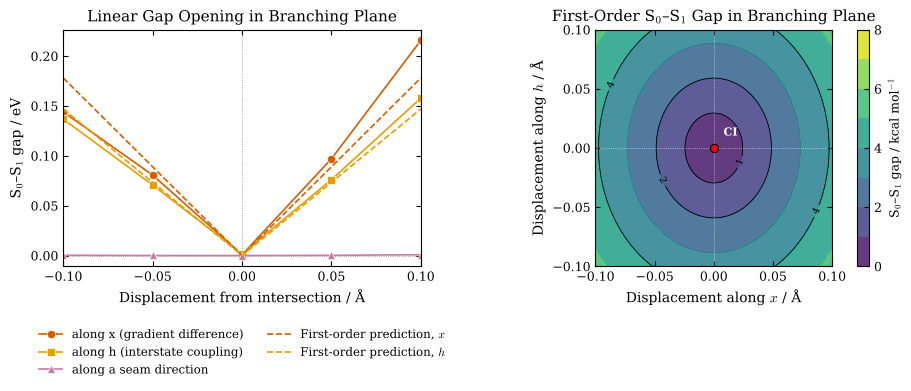

In [12]:
# ==============================================================================
# 1. COLOURS (style and constants come from the setup cell)
# ==============================================================================

# Colours here label DIRECTIONS (Okabe-Ito palette from the setup cell)
COLOR_X = OKABE_ITO["vermillion"]   # x direction
COLOR_H = OKABE_ITO["orange"]       # h direction
COLOR_SEAM = OKABE_ITO["purple"]    # seam direction


# Half-gap slopes in Eh per angstrom (|x| and |h| are in Eh per bohr)
s_x = np.linalg.norm(meci["x"]) / BOHR
s_y = np.linalg.norm(meci["y"]) / BOHR

# ==============================================================================
# 2. FIGURE SETUP
# ==============================================================================
fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(9.0, 3.8),
    gridspec_kw={"width_ratios": [1.0, 1.05]},
    layout="constrained",
)

# ==============================================================================
# 3. LEFT PANEL: 1D Scans Through the Intersection Point
# ==============================================================================
styles = {
    "along x (gradient difference)": dict(
        color=COLOR_X, marker="o", linestyle="-"
    ),
    "along h (interstate coupling)": dict(
        color=COLOR_H, marker="s", linestyle="-"
    ),
    "along a seam direction": dict(
        color=COLOR_SEAM, marker="^", linestyle="-"
    ),
}

for name, (ts, gaps) in scan.items():
    style = styles.get(name, {})
    ax_left.plot(
        ts,
        gaps,
        ms=6.0,
        lw=1.2,
        markeredgecolor="white",
        markeredgewidth=0.5,
        label=name,
        **style,
    )

# Analytical predictions
t = np.linspace(-0.1, 0.1, 401)
abs_t_scale = 2.0 * np.abs(t) * HARTREE_TO_EV

ax_left.plot(
    t,
    s_x * abs_t_scale,
    "--",
    color=COLOR_X,
    lw=1.2,
    label=r"First-order prediction, $x$",
)
ax_left.plot(
    t,
    s_y * abs_t_scale,
    "--",
    color=COLOR_H,
    lw=1.2,
    label=r"First-order prediction, $h$",
)

# Reference lines
ax_left.axvline(0, color="#888888", lw=0.6, ls=":", zorder=1)
ax_left.axhline(0, color="#888888", lw=0.6, ls=":", zorder=1)

ax_left.set(
    xlabel=r"Displacement from intersection / Å",
    ylabel=r"S$_0$–S$_1$ gap / eV",
    xlim=(-0.1, 0.1),
    xticks=[-0.1, -0.05, 0, 0.05, 0.1],
    title="Linear Gap Opening in Branching Plane",
)

ax_left.legend(
    fontsize=8.5,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
)

# ==============================================================================
# 4. RIGHT PANEL: 2D First-Order Conical-Intersection Gap
# ==============================================================================
u = np.linspace(-0.1, 0.1, 301)
v = np.linspace(-0.1, 0.1, 301)

gap = 2.0 * np.hypot(s_x * u[None, :], s_y * v[:, None]) * HARTREE_TO_KCAL

levels = np.arange(0, 9, 1)
cf = ax_right.contourf(u, v, gap, levels=levels, cmap="viridis", alpha=0.85)
cs = ax_right.contour(
    u, v, gap, levels=[1, 2, 4, 6, 8], colors="black", linewidths=0.6
)
ax_right.clabel(cs, inline=True, fontsize=7, fmt="%d")

# intersection point (red dot, as in the 3D plot)
ax_right.scatter(
    [0],
    [0],
    color="red",
    s=35,
    zorder=5,
    edgecolor="black",
    linewidth=0.8,
)
ax_right.annotate(
    "CI",
    xy=(0, 0),
    xytext=(7, 7),
    textcoords="offset points",
    fontsize=8,
    fontweight="bold",
    color="white",
    ha="left",
    va="bottom",
)

ax_right.axhline(0, color="#ffffff", lw=0.6, ls=":", alpha=0.7)
ax_right.axvline(0, color="#ffffff", lw=0.6, ls=":", alpha=0.7)

ax_right.set(
    xlabel=r"Displacement along $x$ / Å",
    ylabel=r"Displacement along $h$ / Å",
    xlim=(-0.1, 0.1),
    ylim=(-0.1, 0.1),
    xticks=[-0.1, -0.05, 0, 0.05, 0.1],
    yticks=[-0.1, -0.05, 0, 0.05, 0.1],
    aspect="equal",
    title=r"First-Order S$_0$–S$_1$ Gap in Branching Plane",
)

cbar = fig.colorbar(cf, ax=ax_right, pad=0.03, fraction=0.046)
cbar.set_label(r"S$_0$–S$_1$ gap / kcal mol$^{-1}$", fontsize=9)
cbar.set_ticks([0, 2, 4, 6, 8])

save_figure(fig, "meci_branching_plane")
plt.show()

cone opening: s_x = 0.0327, s_y = 0.0270 Eh/A;  tilt: c_x = 0.0423, c_y = 0.0249 Eh/A
sigma = 1.59  ->  SLOPED conical intersection


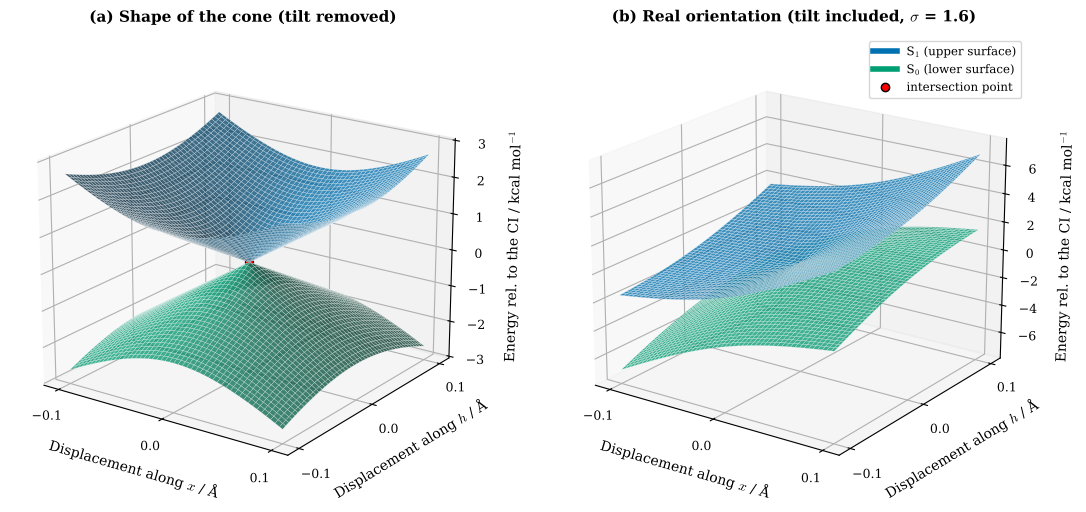

In [13]:
# ==============================================================================
# THE DOUBLE CONE, INCLUDING ITS TILT (first-order model)
# ==============================================================================
# To first order around the intersection point, for displacements u (along x)
# and v (along h), both in angstrom:
#     E_pm(u, v) = c_x u + c_y v  +/-  sqrt( (s_x u)^2 + (s_y v)^2 )
# s_x, s_y : how fast the two states separate (half the gap slope, computed above)
# c_x, c_y : the TILT, i.e. the slope of the average energy (S0 + S1)/2
c_x = (gm @ xh) / BOHR                       # hartree per angstrom
c_y = (gm @ hh) / BOHR
sigma = np.hypot(c_x / s_x, c_y / s_y)       # tilt relative to the opening of the cone
print(f"cone opening: s_x = {s_x:.4f}, s_y = {s_y:.4f} Eh/A;  tilt: c_x = {c_x:.4f}, c_y = {c_y:.4f} Eh/A")
print(f"sigma = {sigma:.2f}  ->  {'SLOPED' if sigma > 1 else 'PEAKED'} conical intersection")

u = np.linspace(-0.1, 0.1, 150)
v = np.linspace(-0.1, 0.1, 150)
U, V = np.meshgrid(u, v)
half_gap = np.hypot(s_x * U, s_y * V) * HARTREE_TO_KCAL
tilt = (c_x * U + c_y * V) * HARTREE_TO_KCAL

fig = plt.figure(figsize=(11.0, 5.0), layout="constrained")
panels = [("(a) Shape of the cone (tilt removed)", 0.0 * tilt),
          (rf"(b) Real orientation (tilt included, $\sigma$ = {sigma:.1f})", tilt)]
for p, (ttl, t_) in enumerate(panels):
    ax = fig.add_subplot(1, 2, p + 1, projection="3d")
    for E, col in ((t_ + half_gap, COLOR_S1), (t_ - half_gap, COLOR_S0)):
        ax.plot_surface(U, V, E, color=col, alpha=0.75, rstride=3, cstride=3,
                        linewidth=0.2, edgecolor="white", antialiased=True)
    ax.scatter([0], [0], [0], color="red", s=35, zorder=10, edgecolor="black", linewidth=0.8)
    ax.set_xlabel(r"Displacement along $x$ / Å", labelpad=6)
    ax.set_ylabel(r"Displacement along $h$ / Å", labelpad=6)
    ax.set_zlabel(r"Energy rel. to the CI / kcal mol$^{-1}$", labelpad=6)
    ax.set_xticks([-0.1, 0, 0.1]); ax.set_yticks([-0.1, 0, 0.1])
    ax.set_title(ttl, pad=10, fontweight="bold")
    ax.view_init(elev=20, azim=-55)
    ax.set_box_aspect([1, 1, 0.8])
ax.legend(handles=[plt.Line2D([0], [0], color=COLOR_S1, lw=4, label=r"S$_1$ (upper surface)"),
                   plt.Line2D([0], [0], color=COLOR_S0, lw=4, label=r"S$_0$ (lower surface)"),
                   plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
                              markeredgecolor="black", label="intersection point")],
          loc="upper right", frameon=True, fontsize=8.5)

save_figure(fig, "conical_intersection_3d")
plt.show()


### What should you see?

The energy gap opens **linearly** as we move away from the intersection along either $\mathbf{x}$ or $\mathbf{h}$. In a one-dimensional plot of the gap, this appears as a **V shape**, rather than the curved minimum you would expect from a simple quadratic dependence.

Seeing the same linear opening in **two independent directions** is the important part. Together, those two directions form the branching plane, and the two-dimensional energy surfaces form the characteristic **double cone**.

Along the seam direction, by contrast, the S₀–S₁ gap remains essentially zero: moving along the seam takes us from one point on the intersection to another without lifting the degeneracy.

This also explains why a conical intersection can act as an **efficient funnel between electronic states**. Near the intersection, nuclear motion and electronic state character become strongly coupled. The molecule can approach the intersection on one potential-energy surface and then continue away on another.

### Peaked or sloped?
The 3D figure shows the cone twice. Panel (a) shows only how the two surfaces separate. Panel (b) adds one more first-order quantity: the **tilt** of the cone, i.e. how steeply the *average* energy $(E_0+E_1)/2$ changes in the branching plane. Comparing the tilt with the opening of the cone gives a single number, $\sigma$:
* $\sigma < 1$: a **peaked** cone. The upper surface slopes down into the intersection from every direction, like a funnel.
* $\sigma > 1$: a **sloped** cone. Both surfaces fall in the same direction, and the intersection sits on a hillside rather than at the bottom of a funnel.

For dioxetane $\sigma \approx 1.6$: the intersection is **sloped**. This matches what you saw in Part 2, where S₀ and S₁ run almost parallel through the biradical region instead of plunging into a single point.

### Is this the *minimum*-energy crossing point?
Look at the average energies printed along the seam direction: they change by a few tenths of a kcal mol⁻¹ while the gap stays at zero. The states stay degenerate, but the energy still slopes slightly *downhill* along the seam. The point we were given is therefore a point **on** the intersection seam, very close to (but not exactly at) the minimum-energy conical intersection (MECI). For the branching-plane analysis this makes no difference, because the conical shape exists at every point of the seam.

> **The important lesson:**
> A conical intersection is not simply a point where two energies happen to become equal. It is a specific structure of the potential-energy surfaces in nuclear-coordinate space.

### Questions

> **Question 3.1.**
> Why does a **one-dimensional scan**, such as the H₂O₂ bond-dissociation scan in Part 1, not provide enough information to distinguish a conical intersection from an avoided crossing? What additional information would you need?

> **Question 3.2.**
> The conical-intersection seam has dimension $3N-8$. For 1,2-dioxetane, $N=8$, so how many dimensions does the seam have? What does the existence of such a high-dimensional seam tell you about how the molecule can reach a conical intersection?

## 4. The same problem, written for a quantum computer

So far, we have described the electronic structure of 1,2-dioxetane using classical quantum chemistry. Now we ask a different question:
> **Can we write exactly the same electronic problem in the language of qubits?**

### 4.1 First, freeze the orbitals: the CASCI problem

Within the six-orbital active space, the electronic Hamiltonian is determined by one- and two-electron integrals, $h_{pq}$ and $(pq|rs)$, which describe how electrons occupy and interact within the active orbitals. These integrals are computed **in a particular set of molecular orbitals**. Change the orbitals, and the integrals — and therefore the Hamiltonian — change too.

Here we take the converged SA-CASSCF orbitals at one geometry in the near-degeneracy region ($r(\mathrm{O{-}O}) = 2.30$ Å) and **freeze** them. With the orbitals fixed, finding S₀ and S₁ within the active space is exactly the **CASCI** problem: build the Hamiltonian in the space of all configurations of 8 electrons in 6 orbitals, and diagonalize it.

So the question for Sections 4 and 5 is precise:

> **Can a quantum circuit solve the CASCI problem for these fixed orbitals?**

Everything that is "quantum" in Sections 4 and 5 replaces the CASCI diagonalization. The orbitals are not touched until Section 6.

### 4.2 From electrons to qubits

A quantum computer does not work directly with fermionic creation and annihilation operators. We therefore need a **fermion-to-qubit mapping**. Here we use the **Jordan–Wigner transformation**, which converts the fermionic Hamiltonian into a sum of Pauli operators acting on qubits.

Because each spatial orbital has two spin orbitals, six spatial orbitals correspond to $6\times2=12$ spin orbitals and therefore **12 qubits**.

The basic correspondence is simple: $|0\rangle$: spin orbital is unoccupied and $|1\rangle$: spin orbital is occupied.

A computational-basis state of the 12 qubits therefore represents one particular pattern of electron occupation. A superposition of such states represents a quantum-mechanical superposition of electronic configurations—the same idea that we encountered earlier when discussing multireference wavefunctions.

### 4.3 Does the mapping change the chemistry?
No.

The Jordan–Wigner transformation is an **exact change of representation**. It does not simplify the Hamiltonian by throwing away configurations or interactions. It simply rewrites the same fermionic problem using operators that a quantum computer can manipulate. **This gives us an important sanity check.**

We can diagonalize the resulting 12-qubit Hamiltonian exactly on a classical computer and compare its lowest singlet eigenvalues with two classical results:
1. a **CASCI** calculation with PySCF in the same frozen orbitals,
2. the **SA-CASSCF** energies you computed at this geometry in Part 2.

If the mapping and conventions are implemented correctly, the qubit Hamiltonian and CASCI must agree to numerical precision.

> **Key lesson:** the quantum-computing step has not yet introduced a quantum approximation. We have taken the same electronic-structure problem and expressed it in a different mathematical language.

The approximations—and the interesting algorithmic questions—come later, when we ask how to obtain these eigenvalues using an actual quantum circuit.

In [14]:
import pennylane as qml

TAG = "OO2.30"          # a geometry inside the near-degeneracy region
h1, h2 = ints[f"{TAG}/h1"], ints[f"{TAG}/h2"]      # integrals in the frozen SA-CASSCF orbitals
ecore  = float(ints[f"{TAG}/ecore"])                # nuclear repulsion + frozen-core energy

H = qml.jordan_wigner(qml.qchem.fermionic_observable(
        np.array([ecore]), h1, np.swapaxes(h2, 1, 3)))
NQ, NE = 12, 8
print("qubits:", NQ, " Pauli terms:", len(H))

Hmat = H.sparse_matrix(wire_order=range(NQ)).real
S2mat = qml.qchem.spin2(NE, NQ).sparse_matrix(wire_order=range(NQ)).real
keep = [i for i in range(2 ** NQ) if bin(i).count("1") == NE]      # 8 electrons
w, v = np.linalg.eigh(Hmat[keep][:, keep].toarray())
spin = np.einsum("ik,ij,jk->k", v, S2mat[keep][:, keep].toarray(), v)
sing = w[np.abs(spin) < 1e-6]

# classical CASCI in exactly the same (frozen) orbitals
X_tag = np.array(next(g["X"] for g in geom if g["tag"] == TAG))
mf_tag = scf.RHF(make_mol(X_tag)); mf_tag.verbose = 0; mf_tag.kernel()
cas = mcscf.CASCI(mf_tag, 6, 8); cas.fcisolver.nroots = 2; cas.verbose = 0
fci.addons.fix_spin_(cas.fcisolver, ss=0)
e_casci = np.array(cas.kernel(orbs[TAG])[0])

r_tag = next(r for r in results if r["tag"] == TAG)      # your own SA-CASSCF run from Part 2
print("lowest singlets of the qubit Hamiltonian:", np.round(sing[:2], 6))
print("CASCI (PySCF), same frozen orbitals     :", np.round(e_casci, 6))
print("SA-CASSCF (Part 2)                      :", np.round([r_tag["S0"], r_tag["S1"]], 6))

qubits: 12  Pauli terms: 1831


lowest singlets of the qubit Hamiltonian: [-227.683589 -227.675307]
CASCI (PySCF), same frozen orbitals     : [-227.683589 -227.675307]
SA-CASSCF (Part 2)                      : [-227.683589 -227.675307]


All three lists agree to the last digit.

* **Qubit Hamiltonian = CASCI.** The qubit Hamiltonian *is* the active-space (CASCI) Hamiltonian, just written in a different language.
* **CASCI = SA-CASSCF, here.** This is not a coincidence, and it is worth understanding: we used the *converged* SA-CASSCF orbitals. At convergence, SA-CASSCF is simply a CASCI calculation in its own optimized orbitals. In any other set of orbitals — for example, Hartree–Fock orbitals — CASCI gives different energies, and usually much higher ones. We will see exactly how much higher in Section 6.

The dense diagonalization above is used only as a **classical check**. It is not how we intend to solve the problem on a quantum computer. For this example, the active space contains only **225 Slater determinants** (which combine into 105 singlet configurations), so constructing and diagonalizing the full Hamiltonian matrix is still easy on a classical computer.

The difficulty is that the number of configurations grows rapidly as the active space becomes larger. Increasing the number of orbitals and electrons can make exact diagonalization impractical very quickly.

> **Key lesson:** the quantum computer does not make this small example easier. We use it because it lets us verify every step. The motivation for quantum algorithms is what happens when the electronic Hilbert space becomes too large for this kind of brute-force classical calculation.

That is the problem we turn to next: **how can a quantum circuit find the energy of the same Hamiltonian without explicitly constructing and diagonalizing its full matrix?**

## 5. VQE, and then SSVQE: one circuit, two states (the quantum counterpart of CASCI)

We now have a 12-qubit Hamiltonian representing exactly the same active-space electronic problem. The next question is:
> **How do we actually extract electronic energies from a quantum circuit?**

### 5.1 VQE: finding the ground state
The **variational quantum eigensolver (VQE)** prepares a trial state using a parameterized quantum circuit,

$$
|\psi(\theta)\rangle = U(\theta)|\mathrm{ref}\rangle,
$$

and measures its energy,

$$
E(\theta)
=
\langle\psi(\theta)|\hat H|\psi(\theta)\rangle
\geq E_0.
$$

A classical optimizer then adjusts the circuit parameters ($\theta$) to lower this energy.

The variational principle guarantees that the measured energy cannot fall below the exact ground-state energy ($E_0$). In a successful calculation, the optimized circuit therefore approaches the ground state.

For our molecule, however, that is not enough.

Near the conical intersection, the ground state S$_0$  and first excited singlet S$_1$ become nearly degenerate. Their relative energies and electronic characters are both important. Finding S$_0$ alone would therefore throw away precisely the excited-state information we spent the previous sections identifying.

### 5.2 SSVQE: finding two states with one circuit

**Subspace-search VQE (SSVQE)** extends the idea by optimizing more than one state at the same time.

We start with two orthogonal reference configurations and pass both through the **same parameterized unitary**:

$$
|\Psi_0\rangle
=
U(\theta)|\mathrm{ref}_0\rangle,
\qquad
|\Psi_1\rangle
=
U(\theta)|\mathrm{ref}_1\rangle .
$$

Because $U(\theta)$ is unitary,

$$
\langle\Psi_0|\Psi_1\rangle
=
\langle\mathrm{ref}_0|\mathrm{ref}_1\rangle
=
0.
$$

The two states therefore remain orthogonal throughout the optimization.

Instead of minimizing the energy of only one state, we minimize the **average energy of the two states**,

$$
E_{\mathrm{avg}}(\theta)
=
\frac{1}{2}
\left(
\langle\Psi_0|\hat H|\Psi_0\rangle
+
\langle\Psi_1|\hat H|\Psi_1\rangle
\right).
$$

The equal weighting is deliberate: it mirrors the equal-weight state averaging used earlier in **SA-CASSCF** to describe the near-degenerate S$_0$ and S$_1$ states. Note, however, that here the weights act only on the *circuit* parameters $\theta$; the orbitals stay frozen.

Once the circuit has been optimized, the two states span the targeted low-energy subspace. We then construct the Hamiltonian in this two-state basis and perform a small classical 2$\times$2 diagonalization. This gives the two adiabatic energies and the corresponding states.

So the division of labour is simple:

* **quantum circuit:** prepares the electronic states;
* **quantum measurements:** provide the Hamiltonian matrix elements;
* **classical 2$\times$2 diagonalization:** separates the two states within the optimized subspace.

### 5.3 What exactly is SSVQE replacing?

Because the orbitals are frozen, SSVQE is solving **the same problem as CASCI** — it just solves it differently:

|                                | CASCI                                   | SSVQE                                          |
| ------------------------------ | --------------------------------------- | ---------------------------------------------- |
| Orbitals                       | fixed                                   | fixed (the same ones)                          |
| Wavefunction                   | linear combination of configurations    | parameterized quantum circuit $U(\theta)$      |
| How the states are found       | build and diagonalize the full CI matrix | minimize $E_{\mathrm{avg}}(\theta)$, then a 2×2 diagonalization |
| Several states                 | yes (several roots)                     | yes (one circuit, two orthogonal references)   |
| Orbital optimization           | no                                      | no                                             |

$$
\boxed{\text{CASCI} \;\longleftrightarrow\; \text{SSVQE}}
\qquad\text{(same Hamiltonian, same orbitals, different solver)}
$$

This is a **conceptual correspondence**, not an equivalence: CASCI is exact within the active space, whereas SSVQE is only as good as its circuit (the ansatz) and its optimizer. So the right way to judge SSVQE is to compare it with **CASCI in the same orbitals**.

### 5.4 Why the ansatz matters

Our circuit is constructed from **spin-adapted singlet single excitations and pair double excitations**. This restricts the variational space to the singlet sector relevant for S$_0$ and S$_1$.

That is important here. We do not want the optimizer to lower the energy by wandering into states with the wrong spin character. Instead, the circuit is designed to explore the singlet electronic configurations that matter for the conical-intersection problem.

> **Key lesson:** VQE asks, *“What is the lowest-energy state I can prepare?”* SSVQE asks a more useful question for this chemistry: *“Can one quantum circuit learn the low-energy subspace containing both S$_0$ and S$_1$?”*

In [15]:
NORB = 6
singles = [(2*i, 2*a) for i in range(NORB) for a in range(i+1, NORB)]
doubles = [(2*i, 2*i+1, 2*a, 2*a+1) for i in range(NORB) for a in range(i+1, NORB)]
REPS = 3
NPAR = REPS * (len(singles) + len(doubles))

def ansatz(theta):
    """Spin-adapted excitation circuit: for each pair of orbitals, one singlet
    single excitation (same angle for alpha and beta) and one pair double."""
    k = 0
    for _ in range(REPS):
        for (p, q) in singles:
            qml.FermionicSingleExcitation(theta[k], wires=list(range(p, q+1)))
            qml.FermionicSingleExcitation(theta[k], wires=list(range(p+1, q+2)))
            k += 1
        for w4 in doubles:
            qml.DoubleExcitation(theta[k], wires=list(w4)); k += 1

def reference(docc, single=None, sign=1):
    """A configuration: 'docc' lists the doubly occupied orbitals; 'single'
    moves one electron i->a and builds the open-shell *singlet* combination."""
    bits = [0]*NQ
    for o in docc: bits[2*o] = bits[2*o+1] = 1
    if single is not None:
        i, a = single; bits[2*i] = 0; bits[2*a] = 1
    qml.BasisState(np.array(bits), wires=range(NQ))
    if single is not None:
        i, a = single
        qml.DoubleExcitation(sign*np.pi/2, wires=[2*i+1, 2*a, 2*i, 2*a+1])

dev = qml.device("lightning.qubit", wires=NQ)
Hop  = qml.SparseHamiltonian(Hmat.tocsr(),  wires=range(NQ))
S2op = qml.SparseHamiltonian(S2mat.tocsr(), wires=range(NQ))

# The two starting configurations: the ones that carry the most weight in the
# SA-CASSCF wavefunctions of S0 and S1 at this geometry. (Near the intersection
# the leading configuration of S0 is no longer the closed-shell one - which is
# exactly the point of the whole module.) "None" means a closed-shell
# configuration; (i, a) means one electron promoted from orbital i to orbital a,
# in the open-shell *singlet* combination.
REF0, REF1 = [(tuple(d), tuple(s) if s else None) for d, s in refs_store[TAG]]
print("reference configurations:", REF0, REF1)

reference configurations: ((0, 1, 2, 3), None) ((0, 1, 2, 3), (2, 4))


In [16]:
# --- first: plain VQE for the ground state ---------------------------------
@qml.qnode(dev, diff_method="adjoint")
def energy0(theta):
    reference(*REF0); ansatz(theta); return qml.expval(Hop)

import scipy.optimize as so
from pennylane import numpy as pnp
grad0 = qml.grad(energy0)
res = so.minimize(lambda x: float(energy0(pnp.array(x, requires_grad=True))),
                  np.zeros(NPAR),                  # starting point: all angles zero
                  jac=lambda x: np.array(grad0(pnp.array(x, requires_grad=True)), float),
                  method="L-BFGS-B", options=dict(maxiter=200))
print(f"VQE ground state        : {res.fun:.6f} Ha")
print(f"CASCI S0, same orbitals: {e_casci[0]:.6f} Ha")
print(f"difference              : {abs(res.fun - e_casci[0])*HARTREE_TO_KCAL:.4f} kcal/mol")

@qml.qnode(dev, diff_method="adjoint")
def spin0(theta):
    reference(*REF0); ansatz(theta); return qml.expval(S2op)

s2_vqe = float(spin0(pnp.array(res.x, requires_grad=True)))

print(f"<S^2> VQE ground state : {s2_vqe:.6e}")

VQE ground state        : -227.683332 Ha
CASCI S0, same orbitals: -227.683589 Ha
difference              : 0.1615 kcal/mol


<S^2> VQE ground state : 6.542873e-22


In [17]:
# --- then: SSVQE for S0 and S1 together ------------------------------------
def sign_for_singlet(ref):
    @qml.qnode(dev)
    def s2(sign):
        reference(ref[0], ref[1], sign); return qml.expval(S2op)
    return 1 if ref[1] is None else (1 if abs(float(s2(1))) < 1e-8 else -1)

SGN = [sign_for_singlet(REF0), sign_for_singlet(REF1)]

def make_nodes(op):
    @qml.qnode(dev, diff_method="adjoint")
    def node(theta, k):
        ref = (REF0, REF1)[k]
        reference(ref[0], ref[1], SGN[k]); ansatz(theta)
        return qml.expval(op)
    return node
E_node, S_node = make_nodes(Hop), make_nodes(S2op)

def cost(theta):                      # state-averaged energy (equal weights!)
    return 0.5 * (E_node(theta, 0) + E_node(theta, 1))
gradc = qml.grad(cost)

# Start near - but not at - the parameters supplied with the notebook, so that you
# can watch the optimizer do its work. (Set noise = 0 to start from the supplied
# values, or use np.zeros(NPAR) to start from scratch: see Question 5.2.)
rng = np.random.default_rng(0)
theta0 = theta_store[TAG] + 0.15 * rng.standard_normal(NPAR)
print("starting cost %.6f" % cost(pnp.array(theta0)))
res = so.minimize(lambda x: float(cost(pnp.array(x, requires_grad=True))), theta0,
                  jac=lambda x: np.array(gradc(pnp.array(x, requires_grad=True)), float),
                  method="L-BFGS-B", options=dict(maxiter=400))
theta = res.x
print("optimised cost %.6f in %d iterations" % (res.fun, res.nit))

@qml.qnode(dev)
def state_vec(theta, k):
    ref = (REF0, REF1)[k]
    reference(ref[0], ref[1], SGN[k]); ansatz(theta); return qml.state()

V = np.column_stack([np.array(state_vec(theta, k)).real for k in (0, 1)])
E_ss = np.linalg.eigvalsh(V.T @ (Hmat @ V))          # 2x2 subspace diagonalisation
print()
print("SSVQE  S0, S1 :", np.round(E_ss, 6), " <S^2> =",
      np.round([float(S_node(theta, k)) for k in (0, 1)], 8))
print("CASCI         :", np.round(e_casci, 6), " (same frozen orbitals)")
print("difference    : %.4f / %.4f kcal/mol" % tuple(abs(E_ss - e_casci) * HARTREE_TO_KCAL))
print("overlap matrix:")
print(np.round(V.T @ V, 10))

starting cost -227.374064


optimised cost -227.679311 in 34 iterations



SSVQE  S0, S1 : [-227.683465 -227.675158]  <S^2> = [ 0. -0.]
CASCI         : [-227.683589 -227.675307]  (same frozen orbitals)
difference    : 0.0782 / 0.0934 kcal/mol
overlap matrix:
[[ 1. -0.]
 [-0.  1.]]


Two states, from one circuit, at a geometry where the two surfaces are only about 0.2 eV apart — and they match **CASCI in the same orbitals** well within 1 kcal mol⁻¹.

The same calculation has been run at *every* geometry along the path, always in the frozen SA-CASSCF orbitals of that geometry (the results are in `reference_results.json`); the cell below plots the comparison across the whole reaction.

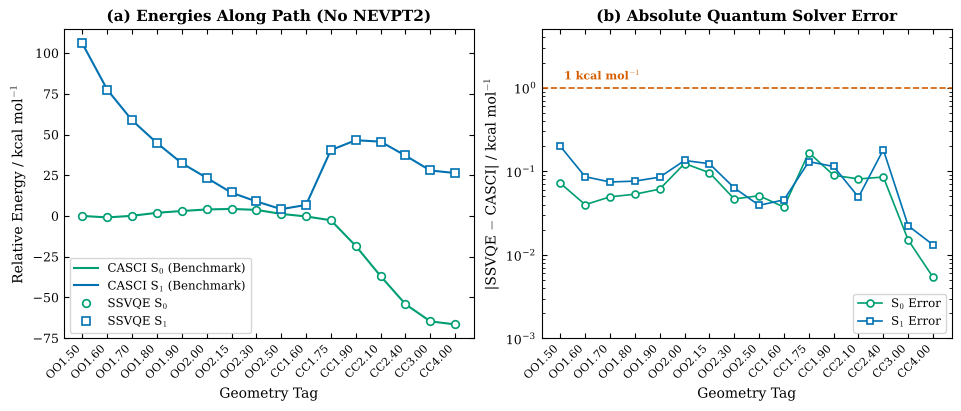

Largest SSVQE error along the path: 0.20 kcal/mol


In [18]:
# ==============================================================================
# 1. COLOURS (style and constants come from the setup cell)
# ==============================================================================

# precomputed SSVQE runs at all 16 geometries (reference_results.json)
COLOR_THRESHOLD = OKABE_ITO["vermillion"]   # 1 kcal/mol reference line

# ==============================================================================
# 2. DATA PROCESSING & CONVERSIONS
# ==============================================================================
q = {x["tag"]: x for x in ref["quantum"]}
tags = [g["tag"] for g in geom]
s = np.arange(len(tags))

# Extract exact classical benchmark (CASCI) and quantum solver (SSVQE)
cas = np.array([[x["exact"][0], x["exact"][1]] for x in (q[t] for t in tags)])
ssv = np.array([[x["Esub"][0], x["Esub"][1]] for x in (q[t] for t in tags)])

# Zero energy reference: ground state CASCI energy at initial point
z = cas[0, 0]

# Relative energies in kcal/mol
E_cas_s0 = (cas[:, 0] - z) * HARTREE_TO_KCAL
E_cas_s1 = (cas[:, 1] - z) * HARTREE_TO_KCAL
E_ssv_s0 = (ssv[:, 0] - z) * HARTREE_TO_KCAL
E_ssv_s1 = (ssv[:, 1] - z) * HARTREE_TO_KCAL

# Absolute solver error in kcal/mol
err_s0 = np.abs(ssv[:, 0] - cas[:, 0]) * HARTREE_TO_KCAL
err_s1 = np.abs(ssv[:, 1] - cas[:, 1]) * HARTREE_TO_KCAL
max_err = max(err_s0.max(), err_s1.max())

# ==============================================================================
# 3. FIGURE INITIALIZATION
# ==============================================================================
fig, (ax_left, ax_right) = plt.subplots(
    1, 2, figsize=(9.5, 4.0), layout="constrained"
)

# ------------------------------------------------------------------------------
# PANEL A: Potential Energy Curves (Benchmark vs Quantum Solver)
# ------------------------------------------------------------------------------
# Classical CASCI exact benchmark (solid lines)
ax_left.plot(
    s, E_cas_s0, "-", color=COLOR_S0, lw=1.5, label=r"CASCI S$_0$ (Benchmark)"
)
ax_left.plot(
    s, E_cas_s1, "-", color=COLOR_S1, lw=1.5, label=r"CASCI S$_1$ (Benchmark)"
)

# Quantum SSVQE solver results (hollow markers)
ax_left.plot(
    s,
    E_ssv_s0,
    "o",
    color=COLOR_S0,
    mfc="white",
    mew=1.2,
    ms=5.5,
    label=r"SSVQE S$_0$",
)
ax_left.plot(
    s,
    E_ssv_s1,
    "s",
    color=COLOR_S1,
    mfc="white",
    mew=1.2,
    ms=5.5,
    label=r"SSVQE S$_1$",
)

ax_left.set_ylabel(r"Relative Energy / kcal mol$^{-1}$")
ax_left.set_title(
    r"(a) Energies Along Path (No NEVPT2)", fontweight="bold"
)
ax_left.legend(fontsize=8.5, frameon=True, loc="lower left")

# ------------------------------------------------------------------------------
# PANEL B: Quantum Solver Absolute Error & Chemical Accuracy Zone
# ------------------------------------------------------------------------------

# Error curves
ax_right.semilogy(
    s,
    err_s0,
    "o-",
    color=COLOR_S0,
    lw=1.2,
    ms=5.0,
    mfc="white",
    mew=1.2,
    label=r"S$_0$ Error",
)
ax_right.semilogy(
    s,
    err_s1,
    "s-",
    color=COLOR_S1,
    lw=1.2,
    ms=5.0,
    mfc="white",
    mew=1.2,
    label=r"S$_1$ Error",
)

# Reference line at 1 kcal/mol
ax_right.axhline(1.0, ls="--", color=COLOR_THRESHOLD, lw=1.2, zorder=2)
ax_right.text(
    s[0] + 0.15,
    1.25,
    r"1 kcal mol$^{-1}$",
    color=COLOR_THRESHOLD,
    fontsize=8,
    fontweight="bold",
)

ax_right.set_ylim(1e-3, 5)
ax_right.set_ylabel(r"|SSVQE $-$ CASCI| / kcal mol$^{-1}$")
ax_right.set_title(r"(b) Absolute Quantum Solver Error", fontweight="bold")
ax_right.legend(fontsize=8.5, frameon=True, loc="lower right")

# ------------------------------------------------------------------------------
# SHARED AXIS LABELS & GEOMETRY TICKS
# ------------------------------------------------------------------------------
for ax in (ax_left, ax_right):
    ax.set_xticks(s)
    ax.set_xticklabels(tags, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Geometry Tag")

# Save high-resolution publication copies
save_figure(fig, "ssvqe_vs_casci_path")

plt.show()

print(f"Largest SSVQE error along the path: {max_err:.2f} kcal/mol")

### What this does and does not show

At this point, we have taken the same chemical problem from classical multireference quantum chemistry to a quantum circuit. But it is important to be precise about what this calculation demonstrates.

* It **does** show that a quantum algorithm can solve the **fixed-orbital multireference problem represented by CASCI**, for two states at once, using a quantum circuit instead of an explicit CI diagonalization. This includes the near-degeneracy of S$_0$ and S$_1$ close to the conical intersection, where a ground-state-only description is insufficient.

* It **does not** show a speed advantage. Everything here runs on an ideal simulator, with no hardware noise and no finite measurement statistics, for an active space that a laptop can diagonalize essentially instantly. A real quantum device would introduce noise, sampling uncertainty, connectivity constraints, and finite circuit depth.

* It is **not yet the quantum analogue of SA-CASSCF**. SSVQE optimizes the wavefunction while keeping the molecular orbitals fixed; here we borrowed orbitals that SA-CASSCF had already optimized classically. SA-CASSCF optimizes both the electronic wavefunctions *and* the orbitals. That missing ingredient is the subject of Section 6.

* Finally, the dynamic correlation treated by NEVPT2 in Part 2 has not disappeared. It must still be recovered outside the active space. Compare the S$_0$ curve in panel (a), which has no NEVPT2 and an almost flat barrier of about 4 kcal mol⁻¹, with the 28 kcal mol⁻¹ barrier in Part 2. Hybrid approaches that use quantum algorithms for the strongly correlated part of the problem and classical methods for the remaining correlation are therefore a natural way to combine the strengths of both approaches.

> **The bigger lesson:** putting chemistry on qubits does not automatically make the chemistry easier. The quantum computer gives us a new representation and, potentially, a new way to handle electronic problems whose Hilbert spaces become too large for classical exact methods. The challenge is to determine when that potential becomes useful in practice.

### Questions

> **Question 5.1.** Why does SSVQE need two *orthogonal* reference states? Why does the unitarity of the circuit mean that their orthogonality is preserved automatically, without an additional orthogonality constraint?

> **Question 5.2.** The optimization above started from a set of supplied parameters. Re-run it from `np.zeros(NPAR)` or from random angles. What happens? What does this tell you about optimization landscapes and initial guesses in variational quantum algorithms?

> **Question 5.3.** Along the whole path, SSVQE and CASCI agree to better than about 0.2 kcal mol$^{-1}$. Is that, by itself, evidence that a quantum computer is useful for this molecule? What additional evidence would you need to establish a practical advantage?

---
## 6. What is still missing? Orbital optimization: SA-OO-VQE

In Section 5 the quantum circuit changed the **wavefunction**, but the underlying **molecular orbitals** never changed: we borrowed them from a classical SA-CASSCF calculation. SA-CASSCF optimizes both the wavefunction *and* the orbitals.

**State-averaged orbital-optimized VQE (SA-OO-VQE)** combines the two ideas: the quantum circuit optimizes the electronic states, while a classical orbital-optimization step updates the orbital basis. Conceptually, it minimizes

$$
E_{\mathrm{SA}}(\theta,\kappa)
=
\frac{1}{2}
\left[
E_0(\theta,\kappa)+E_1(\theta,\kappa)
\right],
$$

where $\theta$ parameterizes the quantum circuit and $\kappa$ parameterizes **orbital rotations**, $\mathbf{C} \rightarrow \mathbf{C}\,e^{-\boldsymbol{\kappa}}$ (with $\boldsymbol{\kappa}$ antisymmetric, so the rotated orbitals stay orthonormal).

> $\theta$ answers *"what electronic wavefunction should I prepare?"*, while $\kappa$ answers *"which orbitals should I use to describe it?"*

### Four methods, one map

|                | States       | Orbitals     | Wavefunction solver           |
| -------------- | ------------ | ------------ | ----------------------------- |
| **CASCI**      | optimized    | **fixed**    | classical diagonalization     |
| **SSVQE**      | optimized    | **fixed**    | quantum circuit               |
| **SA-CASSCF**  | optimized    | **optimized**| classical diagonalization     |
| **SA-OO-VQE**  | optimized    | **optimized**| quantum circuit               |

```text
          fixed orbitals                      optimized orbitals
   CASCI  ───────────────▶  + orbital optimization  ───────────────▶  SA-CASSCF
     ▲                                                                   ▲
     │ same problem, different solver                                    │ same problem, different solver
     ▼                                                                   ▼
   SSVQE  ───────────────▶  + orbital optimization  ───────────────▶  SA-OO-VQE
```

$$
\boxed{\text{CASCI} \leftrightarrow \text{SSVQE}}
\qquad\qquad
\boxed{\text{SA-CASSCF} \leftrightarrow \text{SA-OO-VQE}}
$$

> **A word of caution.** These are *conceptual* correspondences, not mathematically identical methods. SA-OO-VQE is not simply "the quantum version of SA-CASSCF": the ansatz, the optimization landscape, the way the orbitals are parameterized and updated, and the way gradients are evaluated can all differ substantially. The point of this section is not to show that SA-OO-VQE beats SA-CASSCF — it is to show **which ingredient was missing and how it can be added**.

### 6.1 One driver, two solvers

To make the comparison as fair (and as transparent) as possible, we use **the same classical driver** for all four methods: PySCF's `CASCI` and `CASSCF` routines. These routines do not care *how* the active-space states are obtained; they only ask a "solver" for two things:

1. the **energies and wavefunctions** of S$_0$ and S$_1$ for a given set of active-space integrals, and
2. the **state-averaged one- and two-electron reduced density matrices (RDMs)** of those states, $\gamma_{pq}$ and $\Gamma_{pqrs}$.

The RDMs are all that the orbital optimization needs: the state-averaged energy — and its gradient with respect to $\kappa$ — can be written entirely in terms of the integrals and the RDMs,

$$
E_{\mathrm{SA}} = E_{\mathrm{core}} + \sum_{pq} h_{pq}\,\gamma_{pq} + \tfrac12 \sum_{pqrs} (pq|rs)\,\Gamma_{pqrs}.
$$

On a quantum computer, the RDMs would be obtained by measuring expectation values of fermionic operators on the prepared states. Here, on a simulator, we read the state vector directly and translate it into PySCF's configuration-interaction format.

The cell below defines two interchangeable solvers:
* `ExactSolver` — the classical one: diagonalize the active-space Hamiltonian (**CASCI**).
* `SSVQESolver` — the quantum one: the SSVQE circuit from Section 5, applied to whatever orbitals the driver hands it.

Plugging `ExactSolver` into `CASSCF` gives SA-CASSCF; plugging `SSVQESolver` into `CASSCF` gives **SA-OO-VQE**.

In [19]:
from pyscf import ao2mo
from pyscf.fci import cistring
from autograd import value_and_grad

def qubit_hamiltonian(h1, h2, ecore):
    """Jordan-Wigner qubit Hamiltonian (as a sparse matrix) for a set of active-space integrals."""
    Hq = qml.jordan_wigner(qml.qchem.fermionic_observable(np.array([ecore]), h1, np.swapaxes(h2, 1, 3)))
    return Hq.sparse_matrix(wire_order=range(NQ)).real.tocsr()

# Translate a 12-qubit state vector into PySCF's CI matrix c[alpha string, beta string].
# Qubit 2p is orbital p with spin alpha, qubit 2p+1 is orbital p with spin beta.  PySCF orders
# all alpha electrons before all beta electrons, which costs a sign for every (beta, alpha) pair
# that has to be swapped.
_map = []
for idx in keep:                                   # the 8-electron basis states (Section 4)
    bits = [(idx >> (NQ - 1 - q)) & 1 for q in range(NQ)]
    a = [p for p in range(NORB) if bits[2*p]]
    b = [p for p in range(NORB) if bits[2*p + 1]]
    if len(a) == len(b) == NE // 2:
        sign = (-1) ** sum(1 for p in b for qa in a if qa > p)
        _map.append((idx, cistring.str2addr(NORB, NE//2, sum(1 << p for p in a)),
                          cistring.str2addr(NORB, NE//2, sum(1 << p for p in b)), sign))
_map = np.array(_map)
NSTR = cistring.num_strings(NORB, NE // 2)

def qubits_to_ci(vec):
    ci = np.zeros((NSTR, NSTR))
    ci[_map[:, 1], _map[:, 2]] = _map[:, 3] * np.asarray(vec).real[_map[:, 0]]
    return ci

class TwoStateSolver(fci.direct_spin1.FCISolver):
    """Common interface: return S0 and S1, and equal-weight (state-averaged) RDMs."""
    def __init__(self):
        super().__init__(); self.history = []
    def kernel(self, h1, h2, norb, nelec, ci0=None, ecore=0, **kw):
        e, ci = self.solve(h1, ao2mo.restore(1, h2, norb), ecore)
        self.e_states = np.array(e); self.history.append(self.e_states)
        return float(np.mean(e)), ci              # the driver sees the state-averaged energy
    approx_kernel = kernel
    def _avg(self, f, ci, norb, nelec):
        ci = [ci] if isinstance(ci, np.ndarray) else ci
        out = [f(c, norb, nelec) for c in ci]
        return (sum(out) / len(out)) if isinstance(out[0], np.ndarray) else \
               tuple(sum(o[k] for o in out) / len(out) for k in range(len(out[0])))
    def make_rdm1(self, ci, norb, nelec, **kw):  return self._avg(fci.direct_spin1.make_rdm1, ci, norb, nelec)
    def make_rdm1s(self, ci, norb, nelec, **kw): return self._avg(fci.direct_spin1.make_rdm1s, ci, norb, nelec)
    def make_rdm12(self, ci, norb, nelec, **kw): return self._avg(fci.direct_spin1.make_rdm12, ci, norb, nelec)

class ExactSolver(TwoStateSolver):
    """Classical: diagonalize the active-space Hamiltonian (CASCI)."""
    def solve(self, h1, h2, ecore):
        s = fci.addons.fix_spin_(fci.direct_spin1.FCI(), ss=0); s.nroots = 2
        e, ci = s.kernel(h1, h2, NORB, NE, ecore=ecore)
        return e, list(ci)

class SSVQESolver(TwoStateSolver):
    """Quantum: the SSVQE circuit of Section 5 (same ansatz, same references)."""
    def __init__(self, theta0, maxiter=200, **options):
        super().__init__(); self.theta = np.array(theta0, float); self.maxiter = maxiter; self.nit = []
        self.options = options                   # extra L-BFGS-B settings (used in Section 6.5)
    def solve(self, h1, h2, ecore):
        Hq = qml.SparseHamiltonian(qubit_hamiltonian(h1, h2, ecore), wires=range(NQ))
        @qml.qnode(dev, diff_method="adjoint")
        def E(theta, k):
            ref = (REF0, REF1)[k]; reference(ref[0], ref[1], SGN[k]); ansatz(theta)
            return qml.expval(Hq)
        f = value_and_grad(lambda th: 0.5 * (E(th, 0) + E(th, 1)))   # state-averaged cost
        def fun(x):
            val, g = f(pnp.array(x, requires_grad=True)); return float(val), np.array(g, float)
        res = so.minimize(fun, self.theta, jac=True, method="L-BFGS-B",   # warm start from last theta
                          options=dict(maxiter=self.maxiter, **self.options))
        self.theta = res.x; self.nit.append(res.nit)
        V = np.column_stack([np.array(state_vec(self.theta, k)).real for k in (0, 1)])
        Hm = qubit_hamiltonian(h1, h2, ecore)
        e, u = np.linalg.eigh(V.T @ (Hm @ V))                             # 2x2 subspace diagonalization
        V = V @ u
        return e, [qubits_to_ci(V[:, k]) for k in (0, 1)]

# quick self-test in the frozen SA-CASSCF orbitals of Section 4: both solvers vs. CASCI
for solver in (ExactSolver(), SSVQESolver(theta, maxiter=0)):
    ci_run = mcscf.CASCI(mf_tag, 6, 8); ci_run.fcisolver = solver
    ci_run.canonicalization = False; ci_run.verbose = 0; ci_run.kernel(orbs[TAG])
    print(f"{type(solver).__name__:13s}", np.round(solver.e_states, 6),
          " |diff to CASCI| = %.4f / %.4f kcal/mol" % tuple(abs(solver.e_states - e_casci) * HARTREE_TO_KCAL))

ExactSolver   [-227.683589 -227.675307]  |diff to CASCI| = 0.0000 / 0.0000 kcal/mol


SSVQESolver   [-227.683464 -227.675161]  |diff to CASCI| = 0.0786 / 0.0918 kcal/mol


Both solvers reproduce what we saw before: `ExactSolver` *is* CASCI, and `SSVQESolver` (here simply re-using the optimized circuit parameters `theta` from Section 5) reproduces the SSVQE energies. Good — the plumbing works.

### 6.2 Start from orbitals that were *not* optimized for these states

To see what orbital optimization does, we need orbitals that are not already optimal. The most common starting point in quantum chemistry is **Hartree–Fock (HF)**: orbitals optimized for a *single closed-shell determinant*. Near the conical intersection, that is precisely the wrong picture — the molecule is a biradical with two important states.

From the HF orbitals at this geometry we pick the six that most resemble the chemically relevant active orbitals (O–O σ/σ*, C–C σ/σ*, and two oxygen lone pairs). We then run **CASCI** and **SSVQE** in these frozen HF orbitals.

In [20]:
# six HF orbitals that overlap most with the active space: four occupied + two virtual
S_ao = mf_tag.get_ovlp()
weight = ((mf_tag.mo_coeff.T @ S_ao @ orbs[TAG][:, 12:18]) ** 2).sum(axis=1)
nocc = mf_tag.mol.nelectron // 2
act = sorted(list(np.argsort(-weight[:nocc])[:4]) + list(nocc + np.argsort(-weight[nocc:])[:2]))
C_hf = mcscf.sort_mo(mcscf.CASCI(mf_tag, 6, 8), mf_tag.mo_coeff, act, base=0)
print("HF orbitals used as the active space:", [int(i) + 1 for i in act])

def run_casci(solver, C):
    """Fixed orbitals: CASCI with the chosen solver."""
    mc = mcscf.CASCI(mf_tag, 6, 8); mc.fcisolver = solver
    mc.canonicalization = False; mc.verbose = 0; mc.kernel(C)
    return solver.e_states

t0 = time.time()
e_casci_hf = run_casci(ExactSolver(), C_hf)
ssvqe_hf = SSVQESolver(theta_store[TAG])
e_ssvqe_hf = run_casci(ssvqe_hf, C_hf)
print(f"(SSVQE: {ssvqe_hf.nit[-1]} iterations, {time.time()-t0:.0f} s)\n")

ref_S0 = e_casci[0]          # SA-CASSCF S0 at this geometry = our zero of energy
print("energies relative to SA-CASSCF S0 / kcal mol-1       S0       S1")
print("CASCI  in HF orbitals                           %8.2f %8.2f" % tuple((e_casci_hf - ref_S0) * HARTREE_TO_KCAL))
print("SSVQE  in HF orbitals                           %8.2f %8.2f" % tuple((e_ssvqe_hf - ref_S0) * HARTREE_TO_KCAL))
print("CASCI  in SA-CASSCF orbitals (= SA-CASSCF)      %8.2f %8.2f" % tuple((e_casci - ref_S0) * HARTREE_TO_KCAL))

HF orbitals used as the active space: [9, 14, 15, 16, 17, 29]


(SSVQE: 111 iterations, 84 s)

energies relative to SA-CASSCF S0 / kcal mol-1       S0       S1
CASCI  in HF orbitals                              43.48    59.37
SSVQE  in HF orbitals                              43.67    63.14
CASCI  in SA-CASSCF orbitals (= SA-CASSCF)          0.00     5.20


### What should you see?

In the HF orbitals, **both** CASCI and SSVQE place S$_0$ and S$_1$ some **40–60 kcal mol⁻¹ too high**. The solver is not the problem — CASCI is exact within the active space. The *orbitals* are the problem: they were optimized for a closed-shell determinant, not for a balanced description of two biradical states.

You may also notice that SSVQE agrees less well with CASCI in the HF orbitals than it did in the SA-CASSCF orbitals, especially for S$_1$. The same circuit is being asked to do more work: poor orbitals make the wavefunction more complicated, and a fixed-depth ansatz has a harder time representing it.

> **Key lesson:** a fixed-orbital method (CASCI or SSVQE) can only be as good as the orbitals it is given.

### 6.3 Now optimize the orbitals: SA-CASSCF vs. SA-OO-VQE

Both calculations below start from the **same HF orbitals** and use **the same PySCF driver**, in its *two-step* form:

1. **solve** for S$_0$ and S$_1$ in the current orbitals (classically, or with the SSVQE circuit);
2. **rotate the orbitals** to lower $E_{\mathrm{SA}}$, using the state-averaged RDMs from step 1;
3. repeat until neither the energy nor the orbitals change.

The only difference between the two runs is the solver used in step 1.

The classical run takes a few seconds. The SA-OO-VQE run re-optimizes the circuit (warm-started from the previous parameters) after every orbital update and therefore takes several minutes (roughly 3–10, depending on your computer).

In [21]:
def run_sa(solver, C):
    """Optimized orbitals: two-step state-averaged CASSCF driver with the chosen solver."""
    mc = mcscf.CASSCF(mf_tag, 6, 8); mc.fcisolver = solver; mc.verbose = 0
    mc.max_stepsize = 0.05                       # size of the orbital-rotation steps
    mc.conv_tol, mc.conv_tol_grad = 1e-5, 1e-3   # energy (Ha) and orbital-gradient thresholds
    mc.kernel(C, _kern=mcscf.mc2step.kernel)
    return mc

t0 = time.time()
exact_sa = ExactSolver()
mc_sacas = run_sa(exact_sa, C_hf)
print(f"SA-CASSCF : converged = {mc_sacas.converged}, {len(exact_sa.history)} solver calls, {time.time()-t0:.0f} s")

t0 = time.time()
vqe_sa = SSVQESolver(ssvqe_hf.theta)             # warm start from the SSVQE run in HF orbitals
mc_saoo = run_sa(vqe_sa, C_hf)
print(f"SA-OO-VQE : converged = {mc_saoo.converged}, {len(vqe_sa.history)} solver calls, "
      f"{sum(vqe_sa.nit)} circuit-optimization iterations, {time.time()-t0:.0f} s")

e_sacas, e_saoo = exact_sa.e_states, vqe_sa.e_states
print("\nenergies relative to SA-CASSCF S0 (Part 2) / kcal mol-1     S0       S1     average")
for name, e in [("SA-CASSCF, started from HF orbitals", e_sacas),
                ("SA-OO-VQE, started from HF orbitals", e_saoo)]:
    d = (e - ref_S0) * HARTREE_TO_KCAL
    print(f"{name:45s} {d[0]:8.3f} {d[1]:8.3f} {d.mean():8.3f}")
d = (e_casci - ref_S0) * HARTREE_TO_KCAL
print(f"{'SA-CASSCF, Part 2 (reference)':45s} {d[0]:8.3f} {d[1]:8.3f} {d.mean():8.3f}")

# are the optimized active spaces the same?  (singular values of the active-orbital overlap = 1 if identical)
sv = np.linalg.svd(mc_saoo.mo_coeff[:, 12:18].T @ S_ao @ mc_sacas.mo_coeff[:, 12:18], compute_uv=False)
print("\noverlap of the SA-OO-VQE and SA-CASSCF active spaces (1 = identical):", np.round(sv, 4))

SA-CASSCF : converged = True, 8 solver calls, 3 s


SA-OO-VQE : converged = True, 9 solver calls, 494 circuit-optimization iterations, 393 s

energies relative to SA-CASSCF S0 (Part 2) / kcal mol-1     S0       S1     average
SA-CASSCF, started from HF orbitals              0.000    5.197    2.599
SA-OO-VQE, started from HF orbitals              0.761    5.348    3.055
SA-CASSCF, Part 2 (reference)                    0.000    5.197    2.599

overlap of the SA-OO-VQE and SA-CASSCF active spaces (1 = identical): [1.     1.     1.     0.9999 0.9997 0.9991]


### 6.4 Where does the remaining difference come from?

The two runs end with the **same orbitals** (the active-space overlaps above are essentially 1), yet the SA-OO-VQE energies are not quite the SA-CASSCF ones. There are only two possible culprits, and we can separate them exactly:

$$
E_{\text{SA-OO-VQE}} - E_{\text{SA-CASSCF}}
= \underbrace{\big(E_{\text{SA-OO-VQE}} - E_{\text{CASCI}}[\mathbf{C}_{\text{final}}]\big)}_{\text{circuit: SSVQE vs. exact, same orbitals}}
+ \underbrace{\big(E_{\text{CASCI}}[\mathbf{C}_{\text{final}}] - E_{\text{SA-CASSCF}}\big)}_{\text{orbitals}}
$$

where $E_{\text{CASCI}}[\mathbf{C}_{\text{final}}]$ is the **exact** active-space answer in the final SA-OO-VQE orbitals. Computing it costs one CASCI calculation.


In [22]:
C_final = mc_saoo.mo_coeff                         # the converged SA-OO-VQE orbitals
e_exact_final = run_casci(ExactSolver(), C_final)  # exact (CASCI) answer in those orbitals

circuit = (e_saoo - e_exact_final) * HARTREE_TO_KCAL
orbital = (e_exact_final - e_sacas) * HARTREE_TO_KCAL
print("SA-OO-VQE minus SA-CASSCF, split into two parts / kcal mol-1      S0       S1   average")
print(f"{'circuit  (SA-OO-VQE - exact CASCI, same orbitals)':58s} {circuit[0]:8.3f} {circuit[1]:8.3f} {circuit.mean():8.3f}")
print(f"{'orbitals (exact CASCI in SA-OO-VQE orbitals - SA-CASSCF)':58s} {orbital[0]:8.3f} {orbital[1]:8.3f} {orbital.mean():8.3f}")
print(f"{'total':58s} {circuit[0]+orbital[0]:8.3f} {circuit[1]+orbital[1]:8.3f} {(circuit+orbital).mean():8.3f}")


SA-OO-VQE minus SA-CASSCF, split into two parts / kcal mol-1      S0       S1   average
circuit  (SA-OO-VQE - exact CASCI, same orbitals)             0.480    0.507    0.493
orbitals (exact CASCI in SA-OO-VQE orbitals - SA-CASSCF)      0.281   -0.356   -0.037
total                                                         0.761    0.151    0.456


### What does the split tell us?

* **The orbitals are not the problem.** For the *average* energy, the orbital part is essentially zero (a few hundredths of a kcal mol⁻¹; it can even come out slightly *negative*, because near this degeneracy the state-averaged energy changes so little with the orbitals that SA-CASSCF has several almost equivalent solutions). The individual states can each move by a few tenths of a kcal mol⁻¹, in opposite directions. Near a degeneracy, rotating the orbitals slightly can lower one state and raise the other while leaving the average almost unchanged. Only the average is optimized, so only the average is pinned down; this is why comparing the individual S₀ and S₁ energies of two state-averaged methods is less meaningful than comparing their averages.
* **Almost all of the difference is the circuit.** In its own final orbitals, the SSVQE circuit lies about half a kcal mol⁻¹ above the exact answer. The circuit *could* do better: in Section 5 it came within 0.1 kcal mol⁻¹ of CASCI. The optimizer simply stopped too early.

### 6.5 Fixing the circuit optimization

Why did the optimizer stop? Two reasons, both common in variational quantum algorithms:

1. **The stopping rule.** By default, L-BFGS-B stops when the energy changes by less than about $2\times10^{-9}$ *relative* to the energy itself. Our total energy is about 228 hartree, so it gives up as soon as one step gains less than about $5\times10^{-7}$ hartree. The landscape of a 90-parameter circuit has long, flat valleys where progress is slow but steady, so this rule stops the optimizer early. We tighten it (`ftol`, `gtol`).
2. **The starting point.** The circuit was warm-started from the SSVQE solution in the *HF* orbitals and carried along through every orbital update. A warm start keeps the optimizer in whichever valley it started in (compare Question 5.2). The standard remedy is a **multi-start**: optimize again from several starting points and keep the best run.

But how do we decide which run is "best" without peeking at the classical answer?

> **The variational principle decides.** For every run, the state-averaged energy is an *upper bound* to the exact state-averaged energy in these orbitals. The run with the **lowest** state-averaged energy is therefore the best one. No classical reference is needed.

Below, the circuit is re-optimized in the final SA-OO-VQE orbitals from two starting points, the warm start and all angles zero, with the tighter stopping rule and a quasi-Newton memory as long as the number of parameters (`maxcor`). **This cell takes about 3–8 minutes.**


In [23]:
TIGHT = dict(ftol=1e-15, gtol=1e-8, maxcor=NPAR)   # tighter stopping rule, full quasi-Newton memory
starts = {
    "warm start (end of 6.3)": vqe_sa.theta,
    "all angles zero":         np.zeros(NPAR),
}

t0 = time.time()
trials = {}
print(f"{'starting point':26s} {'iterations':>10s} {'E_avg - exact / kcal mol-1':>28s}")
for name, th0 in starts.items():
    s = SSVQESolver(th0, maxiter=400, **TIGHT)
    run_casci(s, C_final)                                       # same orbitals, circuit only
    trials[name] = s
    print(f"{name:26s} {s.nit[-1]:10d} {(s.e_states - e_exact_final).mean() * HARTREE_TO_KCAL:28.3f}")

best = min(trials, key=lambda k: trials[k].e_states.mean())    # lowest average energy wins
e_ms = trials[best].e_states
print(f"\nlowest state-averaged energy: '{best}'   ({time.time()-t0:.0f} s)")

print("\nenergies relative to SA-CASSCF S0 (Part 2) / kcal mol-1          S0       S1   average")
for name, e in [("SA-CASSCF, started from HF orbitals", e_sacas),
                ("exact CASCI in the final SA-OO-VQE orbitals", e_exact_final),
                ("SA-OO-VQE, as in 6.3", e_saoo),
                ("SA-OO-VQE, circuit re-optimized (6.5)", e_ms)]:
    d = (e - ref_S0) * HARTREE_TO_KCAL
    print(f"{name:50s} {d[0]:8.3f} {d[1]:8.3f} {d.mean():8.3f}")


starting point             iterations   E_avg - exact / kcal mol-1


warm start (end of 6.3)           400                        0.207


all angles zero                   400                        0.241

lowest state-averaged energy: 'warm start (end of 6.3)'   (584 s)

energies relative to SA-CASSCF S0 (Part 2) / kcal mol-1          S0       S1   average
SA-CASSCF, started from HF orbitals                   0.000    5.197    2.599
exact CASCI in the final SA-OO-VQE orbitals           0.282    4.841    2.561
SA-OO-VQE, as in 6.3                                  0.761    5.348    3.055
SA-OO-VQE, circuit re-optimized (6.5)                 0.510    5.027    2.769


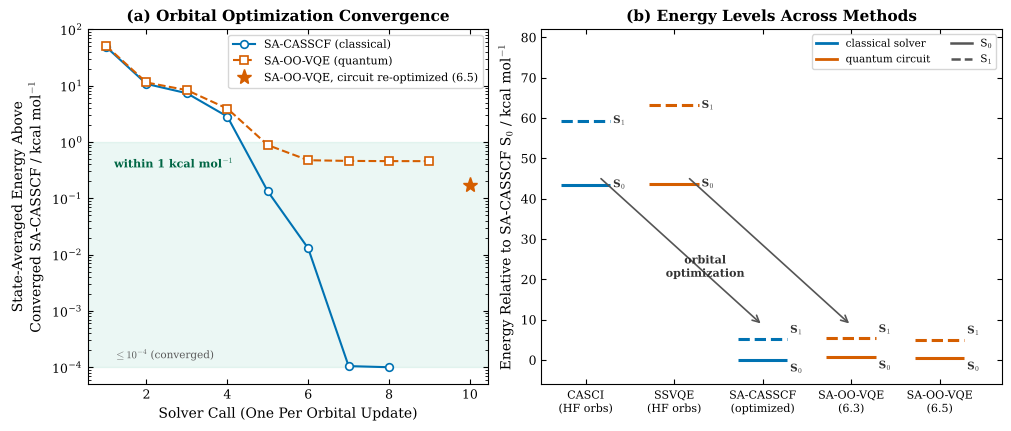

In [24]:
COLOR_CLASSICAL = OKABE_ITO["blue"]        # classical solver (CASCI / SA-CASSCF)
COLOR_QUANTUM = OKABE_ITO["vermillion"]    # quantum circuit (SSVQE / SA-OO-VQE)
COLOR_ACCURACY = OKABE_ITO["green"]
FLOOR = 1e-4                               # values below this are drawn at the floor (log axis)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2), layout="constrained",
                                        gridspec_kw={"width_ratios": [1.0, 1.15]})

# ------------------------------------------------------------------------------
# PANEL A: convergence of the state-averaged energy
# ------------------------------------------------------------------------------
n_single = len(vqe_sa.history)
curves = [
    (exact_sa.history, "SA-CASSCF (classical)", "o-", COLOR_CLASSICAL),
    (vqe_sa.history, "SA-OO-VQE (quantum)", "s--", COLOR_QUANTUM),
]
for hist, lab, mk, col in curves:
    h = np.array(hist).mean(axis=1)
    delta_e = np.maximum((h - e_casci.mean()) * HARTREE_TO_KCAL, FLOOR)
    ax_left.semilogy(range(1, len(h) + 1), delta_e, mk, color=col, mfc="white", mew=1.2, ms=5.5, label=lab)
# the re-optimized circuit of Section 6.5 (same final orbitals), drawn one step to the right
d_ms = max((e_ms.mean() - e_casci.mean()) * HARTREE_TO_KCAL, FLOOR)
ax_left.semilogy([n_single + 1], [d_ms], "*", color=COLOR_QUANTUM, ms=11, label="SA-OO-VQE, circuit re-optimized (6.5)")

ax_left.axhspan(FLOOR, 1.0, color=COLOR_ACCURACY, alpha=0.08, zorder=0)
ax_left.text(1.2, 0.35, r"within 1 kcal mol$^{-1}$", color="#006644", fontsize=8, fontweight="bold")
ax_left.text(1.2, FLOOR * 1.4, r"$\leq 10^{-4}$ (converged)", color="0.35", fontsize=7.5)
ax_left.set_ylim(FLOOR / 2, 100)
ax_left.set_xlabel("Solver Call (One Per Orbital Update)")
ax_left.set_ylabel("State-Averaged Energy Above\n" + r"Converged SA-CASSCF / kcal mol$^{-1}$")
ax_left.set_title("(a) Orbital Optimization Convergence", fontweight="bold")
ax_left.legend(fontsize=8, frameon=True, loc="upper right")

# ------------------------------------------------------------------------------
# PANEL B: energy levels before and after orbital optimization
# ------------------------------------------------------------------------------
cols = [
    ("CASCI\n(HF orbs)", e_casci_hf, COLOR_CLASSICAL),
    ("SSVQE\n(HF orbs)", e_ssvqe_hf, COLOR_QUANTUM),
    ("SA-CASSCF\n(optimized)", e_sacas, COLOR_CLASSICAL),
    ("SA-OO-VQE\n(6.3)", e_saoo, COLOR_QUANTUM),
    ("SA-OO-VQE\n(6.5)", e_ms, COLOR_QUANTUM),
]
for i, (lab, e, col) in enumerate(cols):
    for k, st in enumerate((r"S$_0$", r"S$_1$")):
        y = (e[k] - ref_S0) * HARTREE_TO_KCAL
        ax_right.hlines(y, i - 0.28, i + 0.28, color=col, lw=2.2,
                        linestyles="-" if k == 0 else "--", zorder=3)
        ax_right.text(i + 0.31, y + (2.2 if k == 1 else -2.2) * (y < 10), st, va="center",
                      fontsize=7.5, color="#333333", fontweight="bold")

# arrows from the HF-orbital columns to the optimized columns (positions taken from the data)
y_hf = (np.mean(e_casci_hf) - ref_S0) * HARTREE_TO_KCAL
y_opt = (np.mean(e_sacas) - ref_S0) * HARTREE_TO_KCAL
arrow_props = dict(arrowstyle="->", color="#555555", lw=1.2, mutation_scale=12)
ax_right.annotate("", xy=(2, y_opt + 6), xytext=(0.15, y_hf - 6), arrowprops=arrow_props)
ax_right.annotate("", xy=(3, y_opt + 6), xytext=(1.15, y_hf - 6), arrowprops=arrow_props)
ax_right.text(1.35, 0.5 * (y_hf + y_opt) - 4, "orbital\noptimization", ha="center", va="center",
              fontsize=8, color="#333333", fontweight="bold")

ax_right.set_xticks(range(len(cols)))
ax_right.set_xticklabels([c[0] for c in cols], fontsize=8)
ax_right.set_xlim(-0.5, len(cols) - 0.3)
ax_right.set_ylim(-6, 82)
ax_right.set_ylabel(r"Energy Relative to SA-CASSCF S$_0$ / kcal mol$^{-1}$")
ax_right.set_title("(b) Energy Levels Across Methods", fontweight="bold")
ax_right.legend(handles=[plt.Line2D([0], [0], color=COLOR_CLASSICAL, lw=2, label="classical solver"),
                         plt.Line2D([0], [0], color=COLOR_QUANTUM, lw=2, label="quantum circuit"),
                         plt.Line2D([0], [0], color="#555555", lw=1.8, ls="-", label=r"S$_0$"),
                         plt.Line2D([0], [0], color="#555555", lw=1.8, ls="--", label=r"S$_1$")],
                fontsize=7.5, loc="upper right", frameon=True, ncol=2)

save_figure(fig, "orbital_optimization_vqe")
plt.show()


### What should you see?

* **Both runs find essentially the same orbitals.** Starting from HF orbitals, orbital optimization lowers the state-averaged energy by roughly 50 kcal mol⁻¹ (panel b). SA-CASSCF recovers the energies from Part 2 exactly, and the overlap between the SA-OO-VQE and SA-CASSCF active spaces is essentially 1.
* **They take a similar path.** For the first few orbital updates the two convergence curves in panel (a) lie almost on top of each other, because they use the same orbital-optimization driver. They separate once the SA-OO-VQE energy reaches the accuracy limit of its circuit optimization.
* **The remaining error is in the circuit, not in the orbitals.** The split in Section 6.4 shows that exact CASCI in the SA-OO-VQE orbitals reproduces the SA-CASSCF *average* energy to a few hundredths of a kcal mol⁻¹. Almost all of the difference comes from the circuit optimization. A tighter stopping rule plus a multi-start (Section 6.5) roughly halves or better that difference, and the variational principle alone tells us which run to keep. More iterations shrink it further (the precomputed SSVQE results along the path in Section 5 used up to 2500 iterations and several starting points). That is a real cost of variational quantum algorithms, and it is worth knowing about.
* **Compare averages, not single states.** Near a degeneracy, a tiny orbital rotation can move S₀ up and S₁ down by a few tenths of a kcal mol⁻¹ with almost no change in the average. Only the **state-averaged** energy is variational, so it is the fair number to compare between two state-averaged methods.
* **The classical part is not negligible.** Every orbital update needs the state-averaged RDMs. On real hardware, $\gamma_{pq}$ and $\Gamma_{pqrs}$ must be *measured*, for both states, at every macro-iteration: a much larger measurement budget than for the energy alone.

So the complete conceptual map of this notebook is:

$$
\text{SA-CASSCF}
\;\xrightarrow{\text{freeze orbitals}}\;
\text{CASCI}
\;\xrightarrow{\text{quantum solver}}\;
\text{SSVQE}
\;\xrightarrow{\text{add orbital optimization}}\;
\text{SA-OO-VQE}.
$$

> **The key lesson:** SA-CASSCF provides the classical reference; SSVQE reproduces the multistate wavefunction optimization in a *fixed* orbital basis (the CASCI problem); and SA-OO-VQE shows how orbital optimization can be added back to the quantum workflow. How close it gets to SA-CASSCF is limited by how well the circuit is optimized, not by the orbitals.

> **Going further.** The implementation above is deliberately minimal (about 60 lines) so that every step is visible. A complete, research-grade implementation of SA-OO-VQE — including analytic gradients and non-adiabatic couplings, which are exactly the quantities needed to locate and characterize conical intersections like the one in Section 3 — is available as the open-source package [`saoovqe`](https://pypi.org/project/saoovqe/) (built on Qiskit and Psi4).

### Questions

> **Question 6.1.** CASCI is *exact* within the active space. Why, then, are the CASCI energies in the HF orbitals 40–60 kcal mol⁻¹ above the SA-CASSCF energies? What does this tell you about what "exact within the active space" really means?

> **Question 6.2.** Both SA-CASSCF and SA-OO-VQE minimize the *average* energy of S$_0$ and S$_1$. Which quantity is guaranteed by the variational principle to lie at or above its exact value in a given set of orbitals: the average, or each individual state? Use your answer to explain (i) why the multi-start in Section 6.5 may select a run by its average energy, and (ii) why the individual S$_0$ and S$_1$ energies of SA-OO-VQE can differ from SA-CASSCF in opposite directions.

> **Question 6.3.** In SA-OO-VQE, the orbital update requires the state-averaged one- and two-electron RDMs. For 6 active orbitals, estimate how many independent elements $\Gamma_{pqrs}$ has (ignore symmetry first, then think about which symmetries reduce the number). Why would measuring them on real quantum hardware be expensive?

> **Question 6.4.** Where is the "quantum" part of SA-OO-VQE, and where is the "classical" part? If the active space were made much larger, which part would you expect to become the bottleneck first?

> **Question 6.5.** In Section 6.5, change `maxiter=400` to `maxiter=100` and to `maxiter=1000` (the second takes a while). How does the circuit error change? Why might an optimizer *look* converged when it is not?


## Wrap-up

You started by breaking a peroxide bond and watching a single-determinant description fail for H$_2$O$_2$. You then followed the decomposition of 1,2-dioxetane—from ring opening, through the biradical region, to fragmentation—using a state-averaged multireference method, and identified the region where S$_0$, S$_1$, and T$_1$ become closely spaced.

You then went one step further: rather than simply observing a small energy gap, you demonstrated that the S$_0$/S$_1$ crossing is a **conical intersection** by examining the two directions of its branching plane.

Next, you froze the orbitals, which turned the problem into CASCI, and rewrote the same active-space Hamiltonian on 12 qubits. VQE and SSVQE then recovered the low-energy singlet states, reproducing CASCI in the same orbitals to better than about $0.2\ \mathrm{kcal\,mol^{-1}}$ along the whole reaction path.

Finally, you added the missing ingredient — orbital optimization — and saw that SA-OO-VQE, started from Hartree–Fock orbitals, finds the same orbitals as SA-CASSCF, and, once the circuit itself is optimized carefully (a tighter stopping rule and a multi-start), energies within a few tenths of a kcal mol⁻¹ of SA-CASSCF:

$$
\text{CASCI} \leftrightarrow \text{SSVQE},
\qquad
\text{SA-CASSCF} \leftrightarrow \text{SA-OO-VQE}.
$$

The central lesson is not that a quantum computer has solved the glow-stick problem faster.

It is that the **same electronic structure that makes the chemistry interesting also makes the computational problem difficult**: bonds break, electronic configurations compete, and multiple states become strongly coupled. Those are precisely the situations in which conventional single-reference methods become inadequate—and where new quantum algorithms are being developed to explore strongly correlated electronic structure.

### Extensions

1. **Make the active space larger.**
   Increase the calculation to CAS(10,8) by adding the C–O $\sigma/\sigma^*$ pair. How does the reaction barrier change? Does the region of near-degeneracy move? How many qubits are now required?

2. **Add measurement statistics.**
   Our energies are exact expectation values. On hardware, each expectation value is estimated from a finite number of measurements ("shots"). Measure the Pauli-sum Hamiltonian `H` of Section 4 (a `SparseHamiltonian` cannot be measured shot by shot) with a finite number of shots:

   ```python
   @qml.set_shots(10000)
   @qml.qnode(dev)
   def energy_shots(theta):
       reference(*REF0); ansatz(theta); return qml.expval(H)
   ```

   and evaluate it several times at the optimized VQE parameters. How does the statistical uncertainty in the energy change as the number of shots is increased?

3. **Find the conical intersection yourself.**
   The gradient-projection optimizer is only about 20 lines of code (see `meci.py` in the Supporting Information) and typically converges in about 30 steps. Which quantities define the branching plane, and how does the energy gap change as the optimization proceeds?

4. **SA-OO-VQE along the path.**
   Run SA-OO-VQE at a few other geometries (for example `OO1.50` and `CC4.00`), starting each time from the converged orbitals of a neighbouring point instead of from HF. How many macro-iterations are needed now? Why?

5. **Use a research-grade implementation.**
   Install the [`saoovqe`](https://pypi.org/project/saoovqe/) package (it requires Psi4, which is easiest to install with conda) and compute the S$_0$/S$_1$ energies and the non-adiabatic coupling at the conical-intersection geometry of Section 3. How do the SA-OO-VQE branching-plane vectors compare with the SA-CASSCF ones supplied with this notebook?

6. **Revisit the energy budget.**
   Compute the S$_1$ and T$_1$ energies of *relaxed* formaldehyde and repeat the energy-budget argument for singlet versus triplet chemiexcitation. Does the energetic picture change when the product geometries are allowed to relax?

> **Final question:** What began as a glow stick is really a lesson in electronic structure: when the electrons cannot be described by a single configuration or a single electronic state, both the chemistry and the computation become richer—and much harder.

---
## Summary figure: the whole story in six panels

The cell below collects results you have already computed into one figure (saved as `figures/summary_figure_main_paper.pdf` and `.png`). Read it left to right, top to bottom:

| Panel | What it shows | Where it came from |
| --- | --- | --- |
| **(a)** | Stretching the O–O bond of H₂O₂: σ and σ* occupations approach 1, and UHF loses its spin ($\langle\hat S^2\rangle \to 1$). One configuration is no longer enough. | Part 1 |
| **(b)** | 1,2-Dioxetane → 2 H₂CO: S₀, S₁ and T₁ (SA-CASSCF + NEVPT2) along the path; grey: S₀–S₁ gap below 0.5 eV. | Part 2 |
| **(c)** | In the same region the ground state turns into a biradical: $c_0^2$ falls and $N_u/2$ approaches 1. | Part 2 |
| **(d)** | At the intersection point the gap opens linearly along **x** and **h** and stays closed along the seam: a conical intersection. | Part 3 |
| **(e)** | The same active-space problem on 12 qubits: SSVQE reproduces CASCI for S₀ and S₁ at every geometry. | Part 5 |
| **(f)** | Orbitals matter: frozen HF orbitals put both states 40–60 kcal mol⁻¹ too high; orbital optimization brings SA-CASSCF and SA-OO-VQE to the same orbitals and nearly the same energies. | Part 6 |

**Suggested caption.** *From peroxide bond breaking to a multistate quantum representation.* (a) O–O stretch of H₂O₂ (6-31G*): CASSCF(2,2) natural-orbital occupations of σ and σ*, and ⟨Ŝ²⟩ of the broken-symmetry UHF solution. (b) Decomposition of 1,2-dioxetane: S₀, S₁ (SA-CASSCF(8,6)) and T₁ (CASCI in the same orbitals), all with NEVPT2, relative to the reactant S₀; nine geometries with r(O–O) constrained, then seven with r(C–C) constrained (dotted line); grey bands mark an S₀–S₁ gap below 0.5 eV. (c) Leading-determinant weight $c_0^2$ and half the number of effectively unpaired electrons, $N_u/2$, of the SA-CASSCF S₀ wavefunction. (d) SA-CASSCF S₀–S₁ gap for displacements from the intersection point along the gradient-difference (**x**) and interstate-coupling (**h**) vectors and along a seam direction; dashed lines: first-order prediction. (e) S₀ and S₁ from CASCI (lines) and SSVQE (open symbols) in the frozen SA-CASSCF orbitals of each geometry, relative to CASCI S₀ at the first point. (f) At r(O–O) = 2.30 Å: CASCI and SSVQE in frozen Hartree–Fock orbitals, and SA-CASSCF and SA-OO-VQE (circuit re-optimized in the final orbitals, Section 6.5) after state-averaged orbital optimization, relative to SA-CASSCF S₀; Δ: quantum minus classical, in kcal mol⁻¹. All quantum calculations are noise-free state-vector simulations.


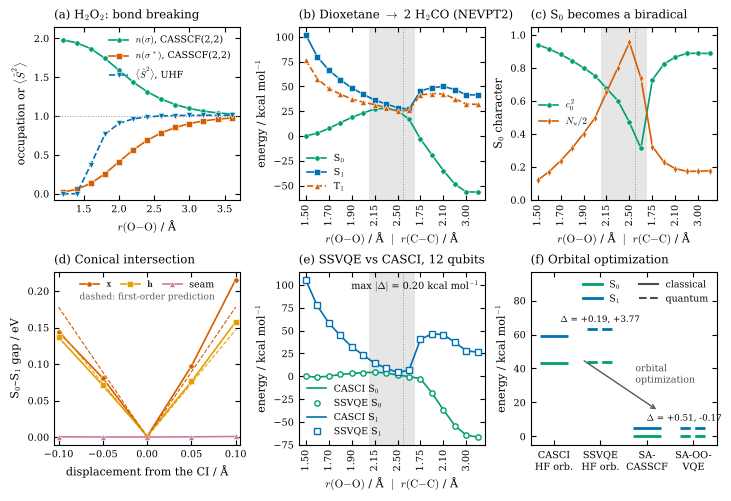

In [25]:
# ==============================================================================
# SUMMARY FIGURE (main paper): six panels, one story
# ==============================================================================
# Everything plotted here was computed (or loaded) earlier in this notebook:
#   rows        -> Part 1 (H2O2)              results -> Part 2 (path, NEVPT2)
#   scan, s_x/y -> Part 3 (intersection)      ref     -> Part 5 (SSVQE along the path)
#   e_*         -> Part 6 (orbital optimization, multi-start SA-OO-VQE)
SMALL = {"font.size": 7.5, "axes.labelsize": 8, "axes.titlesize": 8.5, "legend.fontsize": 6.8,
         "xtick.labelsize": 7, "ytick.labelsize": 7, "lines.linewidth": 1.2, "lines.markersize": 3.8}
MK = dict(markeredgecolor="white", markeredgewidth=0.4)

with plt.rc_context(SMALL):
    fig, axs = plt.subplots(2, 3, figsize=(7.2, 4.9), layout="constrained")
    (ax_a, ax_b, ax_c), (ax_d, ax_e, ax_f) = axs

    # ---------------- (a) H2O2: one bond, two configurations -----------------
    r_h, _, _, _, n1, n2, s2u = map(np.array, zip(*rows))
    ax_a.axhline(1.0, color="0.6", ls=":", lw=0.7)
    ax_a.plot(r_h, n1, "o-", color=COLOR_S0, label=r"$n(\sigma)$, CASSCF(2,2)", **MK)
    ax_a.plot(r_h, n2, "s-", color=COLOR_T1, label=r"$n(\sigma^*)$, CASSCF(2,2)", **MK)
    ax_a.plot(r_h, s2u, "v--", color=COLOR_S1, label=r"$\langle\hat S^2\rangle$, UHF", **MK)
    ax_a.set(xlabel=r"$r(\mathrm{O{-}O})$ / Å", ylabel=r"occupation or $\langle\hat S^2\rangle$",
             title=r"(a) H$_2$O$_2$: bond breaking", ylim=(-0.08, 2.15))
    ax_a.legend(loc="upper right", frameon=False)

    # ---------------- (b) dioxetane: three states along the path --------------
    idx = np.arange(len(results))
    n_oo = sum(r["tag"].startswith("OO") for r in results)
    e0 = results[0]["S0_pt"]
    E = {s: np.array([(r[s + "_pt"] - e0) * HARTREE_TO_KCAL for r in results]) for s in ("S0", "S1", "T1")}
    near = (E["S1"] - E["S0"]) / HARTREE_TO_KCAL * HARTREE_TO_EV < 0.5
    dist_labels = [f"{r['rOO']:.2f}" if r["tag"].startswith("OO") else f"{r['rCC']:.2f}" for r in results]
    for ax in (ax_b, ax_c, ax_e):                                    # common path axis
        for i in idx[near]:
            ax.axvspan(i - 0.5, i + 0.5, color="0.9", lw=0, zorder=0)
        ax.axvline(n_oo - 0.5, color="0.6", ls=":", lw=0.7)
        ax.set_xticks(idx[::2]); ax.set_xticklabels(dist_labels[::2], rotation=90)
        ax.set_xlim(-0.6, len(idx) - 0.4)
        ax.set_xlabel(r"$r(\mathrm{O{-}O})$ / Å  $\vert$  $r(\mathrm{C{-}C})$ / Å")
    ax_b.plot(idx, E["S0"], "o-", color=COLOR_S0, label=r"S$_0$", **MK)
    ax_b.plot(idx, E["S1"], "s-", color=COLOR_S1, label=r"S$_1$", **MK)
    ax_b.plot(idx, E["T1"], "^--", color=COLOR_T1, label=r"T$_1$", **MK)
    ax_b.set(ylabel=r"energy / kcal mol$^{-1}$", title=r"(b) Dioxetane $\rightarrow$ 2 H$_2$CO (NEVPT2)")
    ax_b.legend(loc="lower left", frameon=False)

    # ---------------- (c) how multiconfigurational is S0? ---------------------
    ax_c.plot(idx, [r["c0"] for r in results], "o-", color=COLOR_S0, label=r"$c_0^2$", **MK)
    ax_c.plot(idx, [r["nu"] / 2 for r in results], "d-", color=COLOR_T1, label=r"$N_u/2$", **MK)
    ax_c.set(ylabel=r"S$_0$ character", ylim=(0, 1.05), title=r"(c) S$_0$ becomes a biradical")
    ax_c.legend(loc="center left", frameon=False)

    # ---------------- (d) the conical intersection -----------------------------
    dir_style = {"along x (gradient difference)": (OKABE_ITO["vermillion"], "o", r"$\mathbf{x}$"),
                 "along h (interstate coupling)": (OKABE_ITO["orange"], "s", r"$\mathbf{h}$"),
                 "along a seam direction": (OKABE_ITO["purple"], "^", "seam")}
    t_line = np.linspace(-0.1, 0.1, 201)
    for name, (ts, gaps) in scan.items():
        col, mk, lab = dir_style[name]
        ax_d.plot(ts, gaps, mk + "-", color=col, label=lab, **MK)
    for s_, col in ((s_x, OKABE_ITO["vermillion"]), (s_y, OKABE_ITO["orange"])):
        ax_d.plot(t_line, 2 * s_ * np.abs(t_line) * HARTREE_TO_EV, "--", color=col, lw=0.8)
    ax_d.set(xlabel="displacement from the CI / Å", ylabel=r"S$_0$–S$_1$ gap / eV",
             title="(d) Conical intersection", xlim=(-0.105, 0.105))
    ax_d.legend(loc="upper center", frameon=False, ncol=3, columnspacing=1.0)
    ax_d.text(0.5, 0.84, "dashed: first-order prediction", transform=ax_d.transAxes, ha="center", fontsize=6.5,
              color="0.35")

    # ---------------- (e) SSVQE = CASCI along the whole path -------------------
    qd = {x["tag"]: x for x in ref["quantum"]}
    cas_p = np.array([qd[r["tag"]]["exact"][:2] for r in results])
    ssv_p = np.array([qd[r["tag"]]["Esub"][:2] for r in results])
    z = cas_p[0, 0]
    for k, (col, mk, st) in enumerate(((COLOR_S0, "o", r"S$_0$"), (COLOR_S1, "s", r"S$_1$"))):
        ax_e.plot(idx, (cas_p[:, k] - z) * HARTREE_TO_KCAL, "-", color=col, label=f"CASCI {st}")
        ax_e.plot(idx, (ssv_p[:, k] - z) * HARTREE_TO_KCAL, mk, color=col, mfc="white", mew=1.0,
                  label=f"SSVQE {st}")
    err_max = np.abs(ssv_p - cas_p).max() * HARTREE_TO_KCAL
    ax_e.text(0.97, 0.95, rf"max $|\Delta|$ = {err_max:.2f} kcal mol$^{{-1}}$", transform=ax_e.transAxes,
              ha="right", va="top", fontsize=7)
    ax_e.set(ylabel=r"energy / kcal mol$^{-1}$", title="(e) SSVQE vs CASCI, 12 qubits")
    ax_e.legend(loc="lower left", frameon=False, ncol=1)

    # ---------------- (f) orbital optimization: HF -> SA-CASSCF / SA-OO-VQE ----
    cols_f = [("CASCI\nHF orb.", e_casci_hf, "-"), ("SSVQE\nHF orb.", e_ssvqe_hf, "--"),
              ("SA-\nCASSCF", e_sacas, "-"), ("SA-OO-\nVQE", e_ms, "--")]
    for i, (lab, e, ls) in enumerate(cols_f):
        for k, col in enumerate((COLOR_S0, COLOR_S1)):
            y = (e[k] - ref_S0) * HARTREE_TO_KCAL
            ax_f.hlines(y, i - 0.3, i + 0.3, color=col, lw=2.0, linestyles=ls)
    for i, q, c in ((1, e_ssvqe_hf, e_casci_hf), (3, e_ms, e_sacas)):
        d = (q - c) * HARTREE_TO_KCAL
        y_lab = (q[1] - ref_S0) * HARTREE_TO_KCAL + 4
        ax_f.text(min(i, 2.8), y_lab, rf"$\Delta$ = {d[0]:+.2f}, {d[1]:+.2f}", ha="center", fontsize=6.3)
    y_hf = (np.mean(e_casci_hf) - ref_S0) * HARTREE_TO_KCAL
    ax_f.annotate("", xy=(2.25, 15), xytext=(0.6, y_hf - 6),
                  arrowprops=dict(arrowstyle="->", color="0.35", lw=1.0))
    ax_f.text(1.75, 0.5 * y_hf + 6, "orbital\noptimization", fontsize=6.8, color="0.3", ha="left")
    ax_f.set_xticks(range(4)); ax_f.set_xticklabels([c[0] for c in cols_f])
    ax_f.set(xlim=(-0.5, 3.5), ylim=(-5, 97), ylabel=r"energy / kcal mol$^{-1}$",
             title="(f) Orbital optimization")
    ax_f.legend(handles=[plt.Line2D([0], [0], color=COLOR_S0, lw=2, label=r"S$_0$"),
                         plt.Line2D([0], [0], color=COLOR_S1, lw=2, label=r"S$_1$"),
                         plt.Line2D([0], [0], color="0.3", lw=1.5, ls="-", label="classical"),
                         plt.Line2D([0], [0], color="0.3", lw=1.5, ls="--", label="quantum")],
                loc="upper right", frameon=False, ncol=2)

    for ax in axs.ravel():                                   # panel titles flush left
        ax.set_title(ax.get_title(), loc="left")
        ax.set_title("", loc="center")

    save_figure(fig, "summary_figure_main_paper")
    plt.show()
